# **Hotel Customer Segmentation**

## **Data Understanding** 📊

### Dataset Description
The dataset available in the `HotelCustomersDataset.csv` file represents individual hotel customer data. Each row corresponds to a customer, and each column describes a demographic, behavioral or preference characteristic of that customer. 

Below is a descriptions of all the variables that make up the dataset:

| **Variable**              | **Description**                                                                 |
|---------------------------|---------------------------------------------------------------------------------|
| `ID`            | Unique numeric customer identifier |
| `Nationality`            | Customer's country of origin (ISO code 3166-1 alpha-3) |
| `Age`            | Customer's age (in years) on the last day of the extraction period |
| `DaysSinceCreation`            | Number of days from the creation of the customer record to the end of the extraction period |
| `NameHash`            | SHA2-256 hash of the customer's name (used for anonymisation) |
| `DocIDHash`                | SHA2-256 hash of the ID document provided by the customer at check-in (also for anonymisation) |
| `AverageLeadTime`                | Average time (in days) between the booking date and the customer's arrival date |
| `LodgingRevenue`              | Total spent on accommodation (in euros), including rooms, cots and associated services |
| `OtherRevenue`               | Total spent on other services (in euros), such as food, drinks, spa, etc. |
| `BookingsCanceled`                 | Number of bookings cancelled by the client                 |
| `BookingsNoShowed`                 | Number of bookings in which the client did not show up and did not cancel |
| `BookingsCheckedIn`                | Number of bookings actually made with a stay                           |
| `PersonsNights`                  | Total number of persons x nights that the customer spent at the hotel |
| `RoomNights`         | Total number of rooms x nights used by the customer    |
| `DaysSinceLastStay`         | Days from the customer's last stay to the end of the extraction period. A value of -1 indicates that they have never stayed at the hotel                              |
| `DaysSinceFirstStay`               | Days from the customer's first stay to the end of the extraction period. A value of -1 indicates that they have never stayed at the hotel                             |
| `DistributionChannel`        | Distribution channel most used by the customer (e.g. OTA, agency, direct website)                             |
| `MarketSegment`                | Market segment currently assigned to the customer (e.g. corporate, leisure)                              |
| `SRHighFloor`            | Does the customer usually request rooms on high floors (0: No, 1: Yes)                              |
| `SRLowFloor`       | The customer usually asks for rooms on low floors (0: No, 1: Yes)                                         |
| `SRAccessibleRoom`     | The customer usually asks for accessible rooms (0: No, 1: Yes)                                          |
| `SRMediumFloor`       | The customer usually asks for rooms on medium floors (0: No, 1: Yes)                                     |
| `SRBathtub`         | Do customers usually ask for rooms with a bathtub (0: No, 1: Yes)                           |
| `SRShower`       | The client usually asks for rooms with a shower (0: No, 1: Yes)                      |
| `SRCrib`                 | Does the client usually request a crib (0: No, 1: Yes)                                |
| `SRKingSizeBed`           | The customer usually requests a king-size bed (0: No, 1: Yes)                    |
| `SRTwinBed`               | The customer usually requests a twin bed (0: No, 1: Yes)                         |
| `SRNearElevator`               | The customer usually asks for a room near the lift (0: No, 1: Yes)                         |
| `SRAwayFromElevator`               | The customer usually asks for a room away from the lift (0: No, 1: Yes)                         |
| `SRNoAlcoholInMiniBar`               | The customer usually asks for a minibar without alcohol (0: No, 1: Yes).                         |
| `SRQuietRoom`               | The customer usually asks for a quiet room (0: No, 1: Yes)                        |

🔗 For more information on the structure and content of the dataset, please consult the original scientific article available at:
https://www.sciencedirect.com/science/article/pii/S2352340920314645 

### Libraries

In [1]:
# Ignore the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt # for plots 
import math
import seaborn as sns # for plots
import numpy as np
import scipy.stats as stats
from scipy.stats import zscore # outliers treatment
import pycountry_convert as pc  
from sklearn import preprocessing # MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer
from yellowbrick.cluster import InterclusterDistance

### Import Data

In [2]:
df = pd.read_csv('HotelCustomersDataset.tsv', sep="\t")
df.head()

,ID,Nationality,Age,DaysSinceCreation,NameHash,DocIDHash,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,0x8E0A7AF39B633D5EA25C3B7EF4DFC5464B36DB7AF375...,0x71568459B729F7A7ABBED6C781A84CA4274D571003AC...,45,371.0,105.3,1,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,0x21EDE41906B45079E75385B5AA33287CA09DE1AB86DE...,0x5FA1E0098A31497057C5A6B9FE9D49FD6DD47CCE7C26...,61,280.0,53.0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0x31C5E4B74E23231295FDB724AD578C02C4A723F4BA2B...,0xC7CF344F5B03295037595B1337AC905CA188F1B5B3A5...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,0xFF534C83C0EF23D1CE516BC80A65D0197003D27937D4...,0xBD3823A9B4EC35D6CAF4B27AE423A677C0200DB61E82...,93,240.0,60.0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0x9C1DEF02C9BE242842C1C1ABF2C5AA249A1EEB4763B4...,0xE175754CF77247B202DD0820F49407C762C14A603B3A...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0


Below is an overview of the data types for each variable in the dataset. Additionally, we observe that the only variable containing missing values is `Age`.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    83590 non-null  int64  
 1   Nationality           83590 non-null  object 
 2   Age                   79811 non-null  float64
 3   DaysSinceCreation     83590 non-null  int64  
 4   NameHash              83590 non-null  object 
 5   DocIDHash             83590 non-null  object 
 6   AverageLeadTime       83590 non-null  int64  
 7   LodgingRevenue        83590 non-null  float64
 8   OtherRevenue          83590 non-null  float64
 9   BookingsCanceled      83590 non-null  int64  
 10  BookingsNoShowed      83590 non-null  int64  
 11  BookingsCheckedIn     83590 non-null  int64  
 12  PersonsNights         83590 non-null  int64  
 13  RoomNights            83590 non-null  int64  
 14  DaysSinceLastStay     83590 non-null  int64  
 15  DaysSinceFirstStay 

### Remove Duplicates
**It was confirmed that the dataset contains duplicate records.**

Here, duplicates refers to:

* rows that are identical across all columns,
* rows sharing the same ID,
* or rows with repeated `DocIDHash` or `NameHash` — since each record should uniquely represent a single customer.

In [4]:
# Remove complete duplicates
df = df.drop_duplicates()

# Remove duplicates by 'ID', keeping the first occurrence
df = df.drop_duplicates(subset='ID', keep='first')

# Identify duplicates by DocIDHash or NameHash
mask_duplicates = (
    df.duplicated('DocIDHash', keep=False) |
    df.duplicated('NameHash', keep=False)
)

# Remove ALL lines where DocIDHash OR NameHash are duplicated
df = df[~mask_duplicates]

# View final DataFrame size
df.shape 

(73946, 31)

### Convert variables to the right data type

The **binary variables** were converted from `int` to `bool` to optimize memory usage and more accurately represent their logical nature. This change enhances the clarity of descriptive analysis and supports more intuitive visualizations.

The **nominal variables** such as hashed identifiers and categorical descriptors (e.g., nationality, distribution channel) were converted to category, as they represent labels rather than numerical values. These changes ensure that the data types align with the semantic meaning of the variables, ultimately enhancing both data exploration and model interpretability.

In [5]:
# Conversion of nominal variables
df['Nationality']=df.Nationality.astype('category')
df['NameHash']=df.NameHash.astype('category')
df['DocIDHash']=df.DocIDHash.astype('category')
df['DistributionChannel']=df.DistributionChannel.astype('category')
df['MarketSegment']=df.MarketSegment.astype('category')

# Conversion of binary variables
df['SRHighFloor']=df.SRHighFloor.astype('boolean')
df['SRLowFloor']=df.SRLowFloor.astype('boolean')
df['SRAccessibleRoom']=df.SRAccessibleRoom.astype('boolean')
df['SRMediumFloor']=df.SRMediumFloor.astype('boolean')
df['SRBathtub']=df.SRBathtub.astype('boolean')
df['SRShower']=df.SRShower.astype('boolean')
df['SRCrib']=df.SRCrib.astype('boolean')
df['SRKingSizeBed']=df.SRKingSizeBed.astype('boolean')
df['SRTwinBed']=df.SRTwinBed.astype('boolean')
df['SRNearElevator']=df.SRNearElevator.astype('boolean')
df['SRAwayFromElevator']=df.SRAwayFromElevator.astype('boolean')
df['SRNoAlcoholInMiniBar']=df.SRNoAlcoholInMiniBar.astype('boolean')
df['SRQuietRoom']=df.SRQuietRoom.astype('boolean')

### Descriptive statistics of variables 
#### Numerics

Upon analyzing the descriptive statistics of the numerical variables, we identified some **anomalies and outliers** that require attention. The `Age` variable contains implausible values, such as a **negative age (-11) and an unusually high age (122**), which are most likely due to data entry errors. These anomalies should be addressed during the data cleaning process to ensure data quality. Similarly, `AverageLeadTime`variable also include **negative values**, which is not logically consistent and may represent inconsistent data.

In terms of revenue, both `LodgingRevenue` and `OtherRevenue` exhibit **extreme outliers**, with maximum values of **€21,781** and **€7,730.25** respectively, far above the upper quartile. These may correspond to very specific customer profiles (e.g. high spenders or long-stay booking) and should be further investigated to understand their impact.

Lastly, the variables `BookingsCanceled`, `BookingsNoShowed`, and `BookingsCheckedIn` are mostly concentrated at zero or one, but their maximum values (e.g. **9 cancellations**, **3 no-shows**, and **66 check-ins**) highlight the presence of atypical customer behavior that could be relevant for segmentation.

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,73946.0,42251.722892,24018.107544,3.0,21601.25,42171.5,63140.75,83590.00
Age,73745.0,45.282107,16.695195,-11.0,33.00,46.0,57.00,122.00
DaysSinceCreation,73946.0,447.567089,310.762115,0.0,174.00,387.0,705.00,1095.00
AverageLeadTime,73946.0,68.634477,88.897864,-1.0,0.00,33.0,107.00,588.00
LodgingRevenue,73946.0,303.059723,361.791829,0.0,59.00,238.5,411.00,9682.40
OtherRevenue,73946.0,68.377295,111.531467,0.0,2.00,42.0,90.00,7730.25
BookingsCanceled,73946.0,0.000609,0.042406,0.0,0.00,0.0,0.00,9.00
BookingsNoShowed,73946.0,0.000135,0.013759,0.0,0.00,0.0,0.00,2.00
BookingsCheckedIn,73946.0,0.772861,0.525899,0.0,1.00,1.0,1.00,57.00
PersonsNights,73946.0,4.776215,4.570380,0.0,1.00,4.0,8.00,73.00


#### Categorical

When analysing the descriptive statistics of the categorical variables, we can see that the `Nationality` variable shows high diversity with 188 unique values, with France (FRA) being the most common, appearing 12,422 times (corresponding to 14.86%). 

There is a clear predominance of the 'Travel Agent/Operator' in `DistributionChannel` and 'Other' in `MarketSegment`, reflecting that customer bookings are mostly concentrated in a few specific segments.

In [7]:
df.describe(include=['category']).transpose()

,count,unique,top,freq
Nationality,73946,187,FRA,11912
NameHash,73946,73946,0x000074AF732797316B9EE5A8D5D4807D66B2D9DAC516...,1
DocIDHash,73946,73946,0x0000108140F2C5096749EBCA8C52DDBDBCBD20D63E56...,1
DistributionChannel,73946,4,Travel Agent/Operator,62114
MarketSegment,73946,7,Other,43331


#### Boolean 
The analysis of the variables related to special requests made by customers (`SR*`) shows that, overall, **most customers do not tend to make specific requests** during their stays.

Most of these variables show a very low frequency of `True` values (less than 10%), with **a few exceptions**, such as requests for **king-size beds** or **twin beds**, which appear more frequently.

This pattern suggests that the typical customer behavior tends to be **less personalized**, with specific preferences occurring only in **isolated cases or within certain customer segments**.

In [8]:
# Filter only boolean columns 
bool_cols = df.select_dtypes(include='bool')

# Calculate percentages
percent_true = bool_cols.mean() * 100  # % of True
percent_false = (1 - bool_cols.mean()) * 100  # % of False

# Merge into a Dataframe for a better visualization
percent_df = pd.DataFrame({
    '% True': percent_true.round(2),
    '% False': percent_false.round(2)
})

percent_df 

,% True,% False
SRHighFloor,4.9,95.1
SRLowFloor,0.15,99.85
SRAccessibleRoom,0.02,99.98
SRMediumFloor,0.07,99.93
SRBathtub,0.3,99.7
SRShower,0.18,99.82
SRCrib,1.33,98.67
SRKingSizeBed,35.68,64.32
SRTwinBed,14.65,85.35
SRNearElevator,0.03,99.97


### Missing Values Analysis
The variable `Age` is the only one with missing values. Considering the variables available in the dataset, **there are no features with a strong or logical relationship to `Age` that would allow for reliable imputation**. Since the records with missing `Age` values represent only **4.52%** of the dataset, the decision was made to remove them in order to maintain the quality and integrity of the analysis without introducing artificial bias.

In [9]:
# Missing Value Checking
print('Number of missing values:\n', df.isnull().sum())

Number of missing values:
 ID                        0
Nationality               0
Age                     201
DaysSinceCreation         0
NameHash                  0
DocIDHash                 0
AverageLeadTime           0
LodgingRevenue            0
OtherRevenue              0
BookingsCanceled          0
BookingsNoShowed          0
BookingsCheckedIn         0
PersonsNights             0
RoomNights                0
DaysSinceLastStay         0
DaysSinceFirstStay        0
DistributionChannel       0
MarketSegment             0
SRHighFloor               0
SRLowFloor                0
SRAccessibleRoom          0
SRMediumFloor             0
SRBathtub                 0
SRShower                  0
SRCrib                    0
SRKingSizeBed             0
SRTwinBed                 0
SRNearElevator            0
SRAwayFromElevator        0
SRNoAlcoholInMiniBar      0
SRQuietRoom               0
dtype: int64


### Visualization Distribution of all Categorical Variables

🧳 **Market Segment:**

The majority of customers (over half) fall under the **"Other"** market segment. Additionally, the number of customers in the **"Travel Agent/Operator"** and **"Direct"** segments is quite similar, indicating a balanced distribution between these two booking profiles.

🌐 **Distribution Channel:**

It is evident that **more than half of the customers (around 68,000)** made their bookings through **travel agencies**, followed by **Direct** bookings (customers who book directly with the hotel), and then by **Corporate** and **Electronic Distribution** 

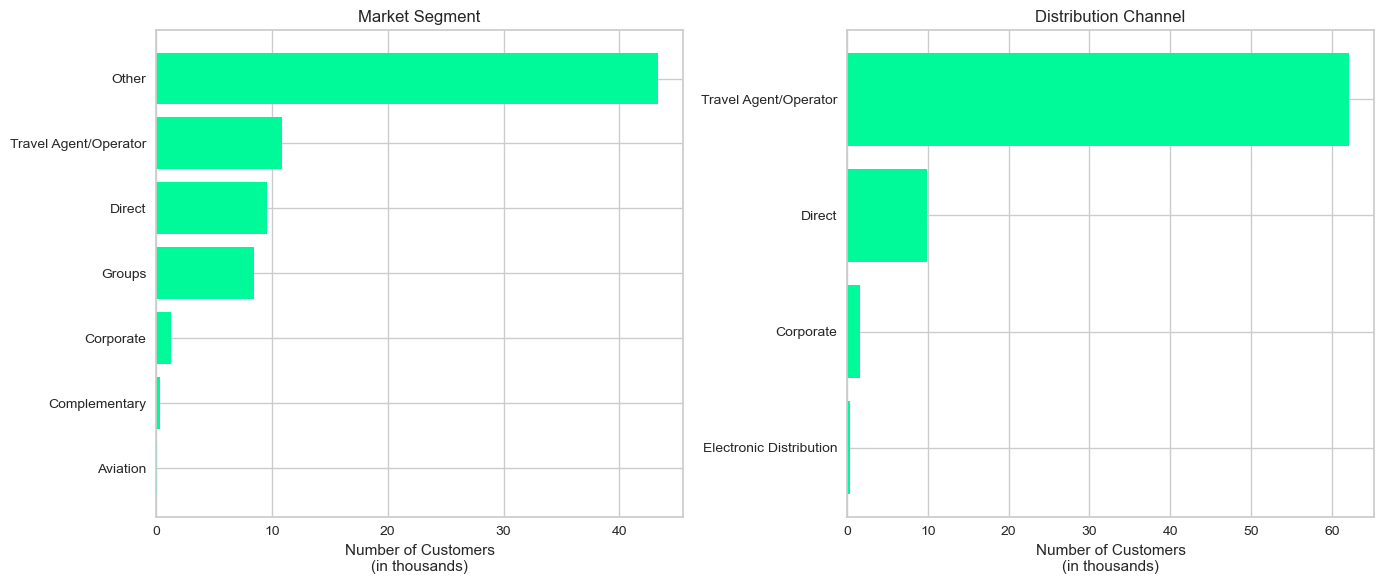

In [10]:
# Group and count the values ​​of each variable
# Fot MarketSegment
market_counts = df['MarketSegment'].value_counts().sort_values(ascending=True) / 1000  # divide by a thousand
# For DistributionChannel
channel_counts = df['DistributionChannel'].value_counts().sort_values(ascending=True) / 1000

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

# Chart 1: MarketSegment
axes[0].barh(market_counts.index, market_counts.values, color='mediumspringgreen')
axes[0].set_title('Market Segment')
axes[0].set_xlabel('Number of Customers\n(in thousands)')

# Chart 2: DistributionChannel
axes[1].barh(channel_counts.index, channel_counts.values, color='mediumspringgreen')
axes[1].set_title('Distribution Channel')
axes[1].set_xlabel('Number of Customers\n(in thousands)')

plt.tight_layout()
plt.show()

### Visualization Distribution of all the Numeric Variables 

It is evident that all numerical variables, except for `Age` and `DaysSinceCreation`, exhibit a highly right-skewed distribution.

Additionally, variables such as `LodgingRevenue`, the booking-related variables (`BookingsNoShowed`, `BookingsCanceled`, `BookingsCheckedIn`), `RoomNights`, `OtherRevenue`, and `PersonsNights` are heavily concentrated within narrow intervals, with most values close to the minimum, which limits the visible variability in the histograms.

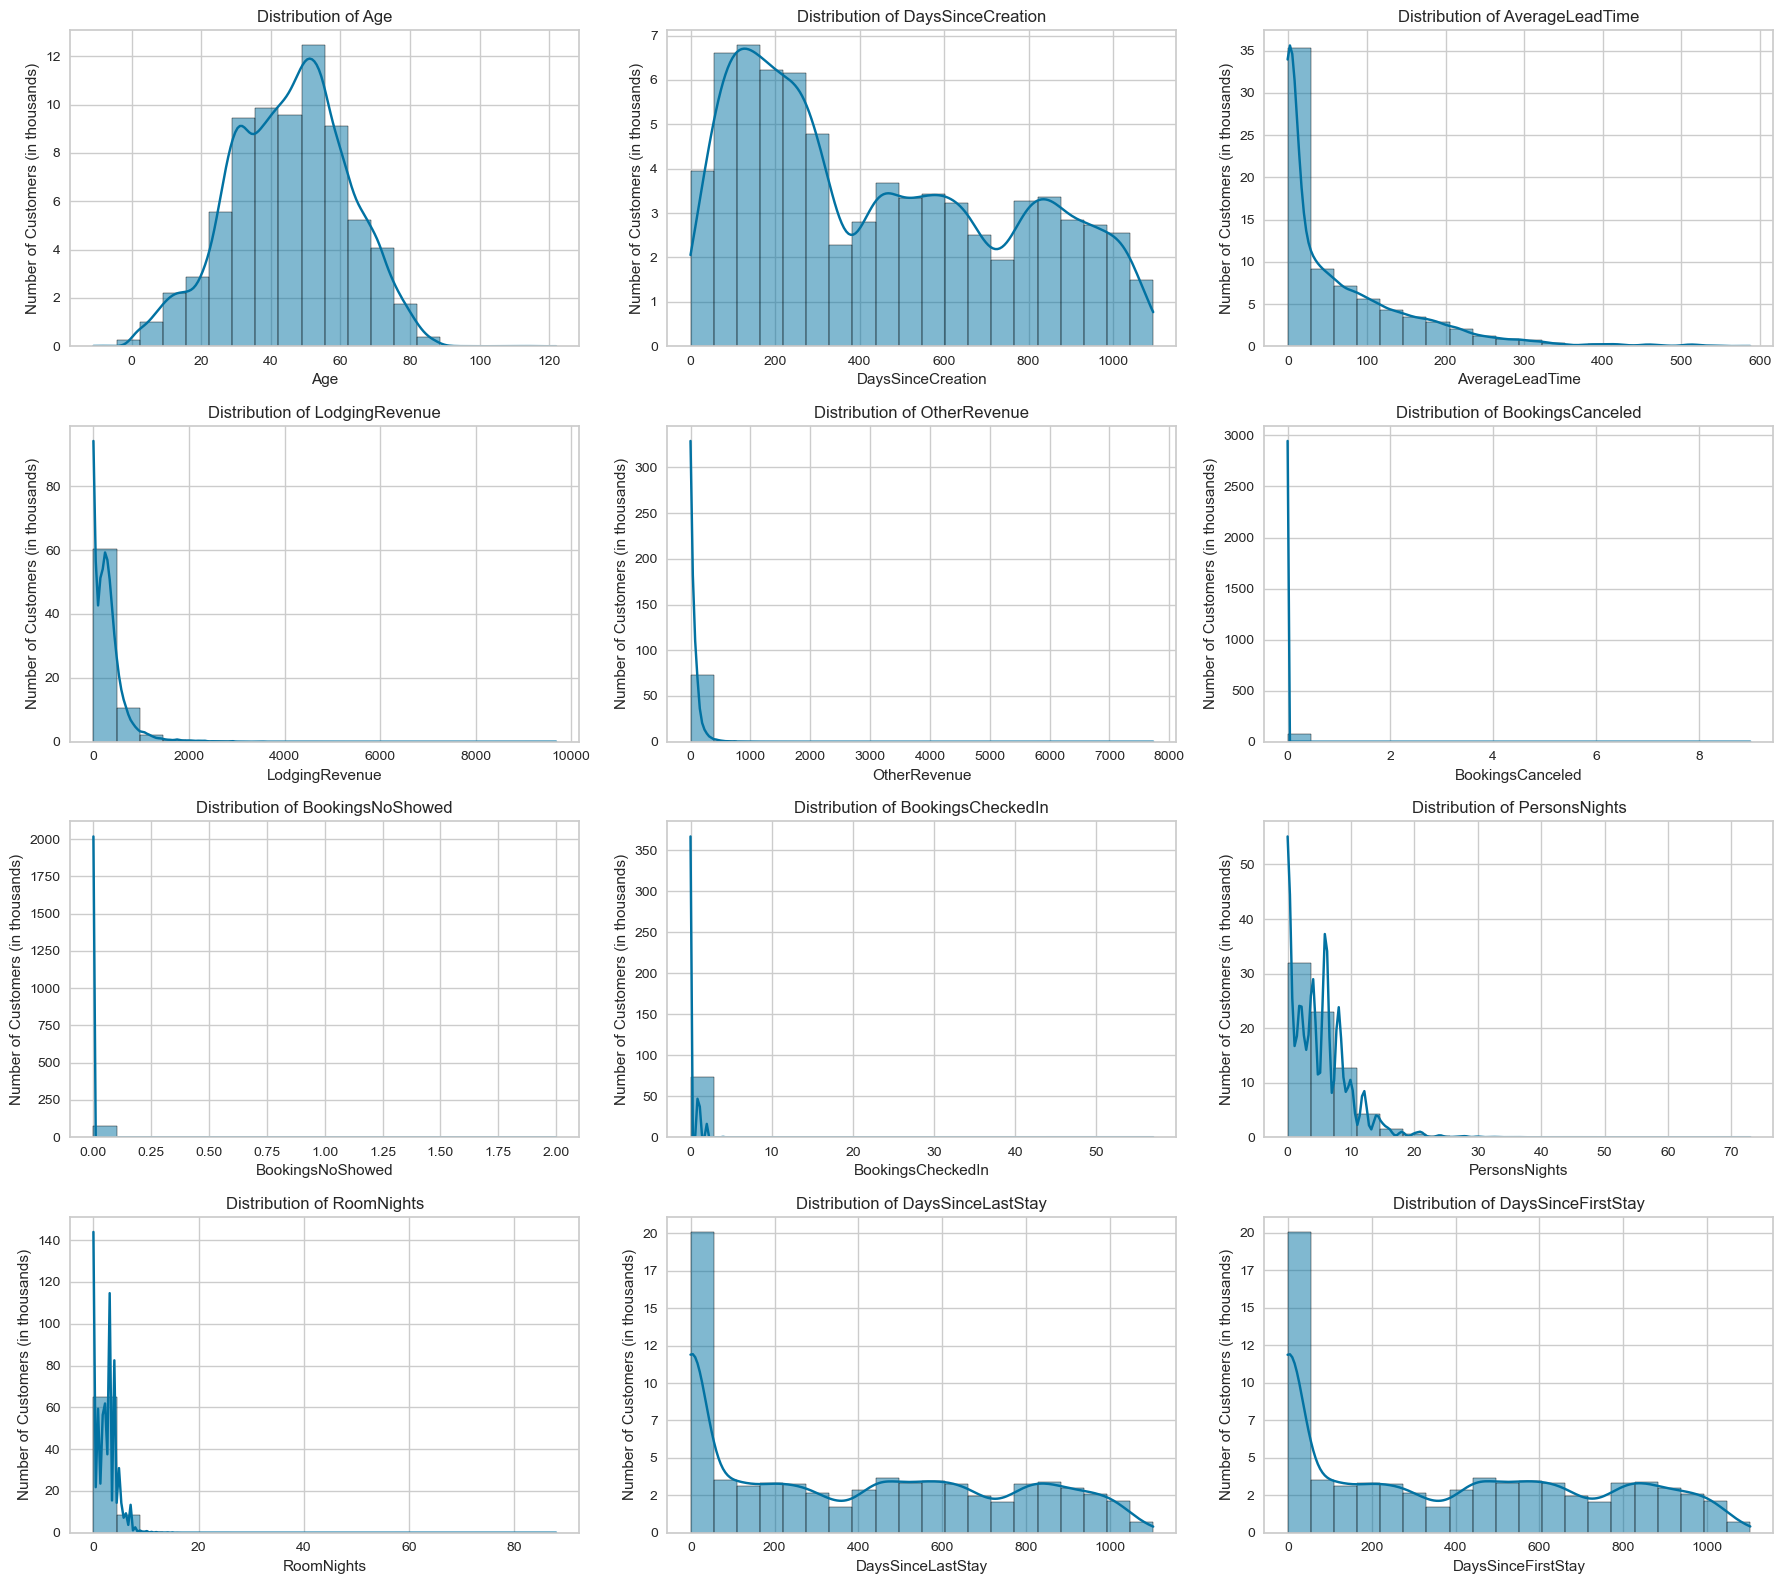

In [11]:
# List of the numerical variables
numeric_vars = df.select_dtypes(include='number').drop(columns=['ID'])

# Subplots (3 rows, 4 columns)
# Total number of variables and columns per row
num_vars = len(numeric_vars.columns)
cols = 3
rows = math.ceil(num_vars / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()  

# Crete histograms
for i, var in enumerate(numeric_vars.columns):
    ax = axes[i]
    sns.histplot(df[var], bins=20, kde=True, ax=ax)
    ax.set_title(f'Distribution of {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Number of Customers (in thousands)')

    # Adjust the Y-axis to show in thousands
    y_labels = ax.get_yticks()
    ax.set_yticklabels([f'{int(label / 1000)}' for label in y_labels])

plt.tight_layout()
plt.show()

### Outlier Analysis 
As expected, the numerical variables contain outliers. Notably, variables such as `LodgingRevenue`, `OtherRevenue`, `PersonsNights`, `RoomNights`, and `BookingsCheckedIn` stand out with extreme values.

Furthermore, the variable `Age`  contains clearly invalid entries, including negative values, ages above 100, and even some entries below 18. These values are not realistic and are likely due to errors during data collection or entry. As such, these records will be removed during the Data Preparation phase.

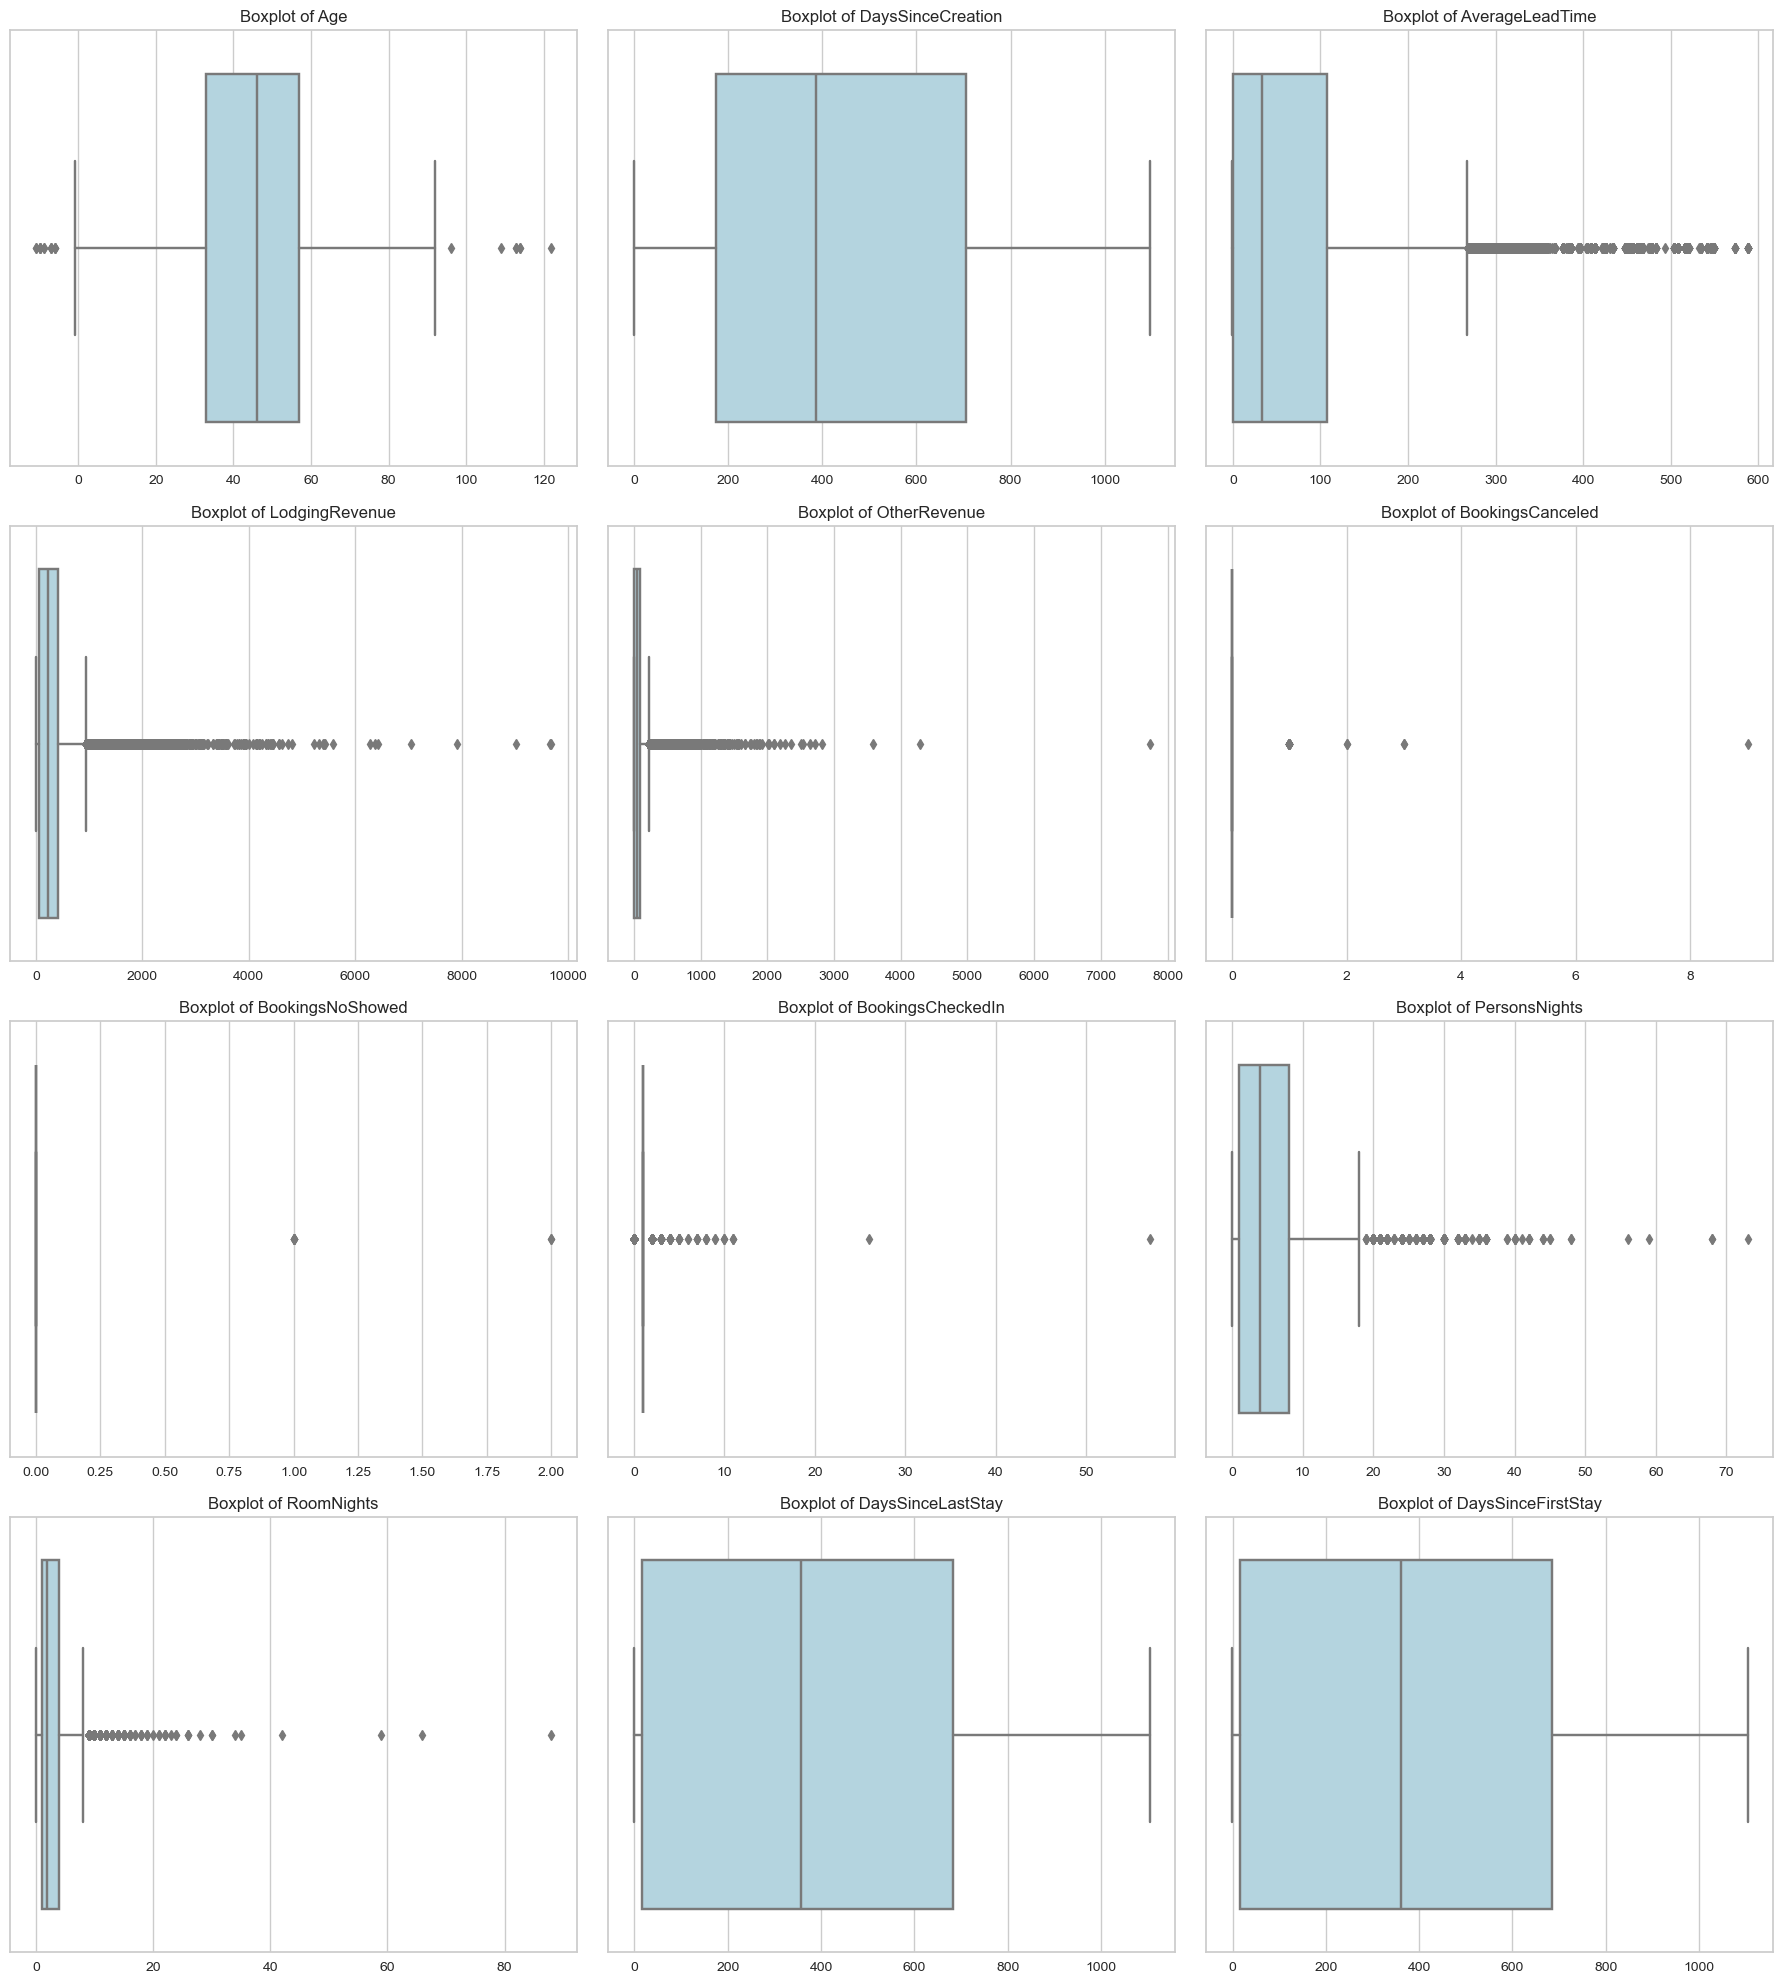

In [12]:
var_names = numeric_vars.columns.tolist()

# Group into blocks of 3 variables
n_vars = len(var_names)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()  # Para facilitar o acesso

# Create each boxplot
for i, var in enumerate(var_names):
    sns.boxplot(x=df[var], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {var}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

---

## Data Preparation 👨🏻‍💻

### Missing Values Treatment
As stated in the missing values ​​analysis, it was decided to eliminate records that have 'Age' as null.

In [13]:
df = df[df['Age'].notna()] 
df.shape 

(73745, 31)

### Outliers Treatment

#### **Age**
Through the boxplot, it was observed that there are customers under the age of 18, which is not legally acceptable, as minors are not allowed by law to make hotel reservations independently.

In [14]:
df = df[~((df['Age'] < 18) | (df['Age'] >= 100))] 

#### **Average Lead Time** 
Only 9 records were found with a negative AverageLeadTime, which is inconsistent, as it suggests that the customer made a reservation after arriving at the hotel. Therefore, these records were removed from the dataset, as they represent only about 0.013% of the total data and are likely due to data entry errors.

In [15]:
df = df[~(df.AverageLeadTime < 0)] 

#### **Bookings Canceled** 
The boxplot of this variable shows that there are customers whose number of cancelled bookings is considerably different from the rest. 
Below you can see the number of clients for each unique value of Bookings Cancelled.

In [16]:
df.BookingsCanceled.value_counts()

BookingsCanceled
0    69527
1       24
2        2
3        2
9        1
Name: count, dtype: int64

**Although the customers analyzed had ⁠ BookingsCancelled ⁠ values higher than the majority (whose value is 0), they are not considered outliers.** This decision is based on the qualitative analysis carried out, which identified plausible justifications for the high number of cancellations. 

For example:
* ⁠One of the clients works in the **aviation** sector, where unforeseen events and last-minute changes are frequent, which may justify the recurrent cancellation of bookings. 
* Another client was traveling in a **corporate** context, where bookings are often subject to change due to professional commitments.
* ⁠An additional case refers to a **“Complementary”** type booking, possibly associated with an **influencer**, which also deviates from the typical customer pattern.

Furthermore, in the other variables observed, **no relevant discrepancies** were detected, reinforcing the decision to **not treat these customers as outliers** in the context I can adjust.

In [17]:
pd.set_option('display.max_columns', None) # Enables to see all the columns

df[df['BookingsCanceled'].isin([2, 3, 9])] 

,ID,Nationality,Age,DaysSinceCreation,NameHash,DocIDHash,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,PersonsNights,RoomNights,DaysSinceLastStay,DaysSinceFirstStay,DistributionChannel,MarketSegment,SRHighFloor,SRLowFloor,SRAccessibleRoom,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
5112,5113,ESP,54.0,982,0xD7408ECC1CD0468A89D77A67A343C3709BE50B5E6920...,0x85AF79BD58FA0971C0B4833F606C643AF2F7101EB94C...,12,772.00,267.15,2,0,2,8,8,822,986,Corporate,Aviation,False,False,False,False,False,False,False,False,False,False,False,False,False
5146,5147,PRT,44.0,981,0x05F32CDE3DB972EBDF984C3DBB1DCBB562DA714173B6...,0x26F1D6C42B7B41C01713E353BB9A2C56F1CCF57E3301...,148,1069.89,276.50,3,0,7,24,11,108,983,Direct,Direct,False,False,False,False,False,False,False,True,False,False,False,False,False
9831,9832,PRT,53.0,905,0x164035B07C5142210CD9B1E26CB5C605BCC9866CD3DD...,0x5459669A28C538DDA12B71126CFFDE06F349144D174C...,8,599.00,112.00,3,1,9,12,10,334,906,Corporate,Corporate,False,False,False,False,False,False,False,True,False,False,False,False,False
11480,11481,PRT,19.0,879,0x8BE9866746E612734661C39DA7E66B924F45133ADE21...,0x396B7C775F86B45E3196F76C210159BC9846810EF00D...,2,195.75,79.00,9,0,57,73,66,27,1075,Direct,Complementary,False,False,False,False,False,False,False,True,False,False,False,False,False
47026,47027,USA,37.0,309,0x5B684A408B2F561BE0FC4143368EC94EB853B99055CB...,0x9FFC9DCA4F464C970F55CC1D04E3D9554C8BE2CE786D...,0,0.00,0.00,2,0,0,0,0,-1,-1,Direct,Direct,False,False,False,False,False,False,False,False,False,False,False,False,False


#### **Bookings No Showed** 

**During the analysis, some customers were identified with higher values in the `BookingsNoShowed` variable, which could initially be interpreted as discrepant values.** However, it was decided **not to eliminate these customers**, since doing so would remove profiles that reflect **real and common behaviors in the hotel context**, compromising the representativeness of the database. 

In addition, it was noted that some of these customers had **equal values in `DaysSinceFirstStay` and `DaysSinceLastStay`**, which indicates that they had **only one stay at the hotel**. When analysing the respective market segments, it was found that they mostly belong to the **aviation**, **corporate** and **travel agency** sectors. This suggests that these one-off stays may correspond to **stopover, short-stay or business trips**, where the customer **has only stayed once**. 

This type of behavior is consistent with the hotel's service usage profile and, although the `BookingsNoShowed` values are above average, they were **not considered outliers**, as the **remaining variables did not show discrepancies** and represent **real cases that should be kept** to guarantee a more faithful and complete analysis of customer behavior.

In [18]:
df.BookingsNoShowed.value_counts()

BookingsNoShowed
0    69548
1        6
2        2
Name: count, dtype: int64

In [19]:
df[df['BookingsNoShowed'].isin([1, 2])] 

,ID,Nationality,Age,DaysSinceCreation,NameHash,DocIDHash,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,PersonsNights,RoomNights,DaysSinceLastStay,DaysSinceFirstStay,DistributionChannel,MarketSegment,SRHighFloor,SRLowFloor,SRAccessibleRoom,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
378,379,PRT,44.0,1091,0x66E8F5833914A4489E20950AD6D24B8B356E5147D0F7...,0x09BF2E3F0D4A09767812429118C5E556258E364C8F86...,2,1086.0,162.00,0,1,11,22,18,189,1084,Corporate,Corporate,False,False,False,False,False,False,False,False,True,False,False,False,False
928,929,ESP,56.0,1061,0x0D94BB1957B94A1A1E934B84BECC99D4C1AEA9E57933...,0x15E855F49720845ECB38562D8B7E6B3EDD02AF0CA7B4...,3,219.0,32.50,0,2,1,3,3,1064,1064,Direct,Direct,False,False,False,False,False,False,False,False,False,False,False,False,False
6912,6913,HRV,59.0,951,0xC8EAEF0B1D7CAFAE49E2B61B3938D848664D4C714859...,0x6215252E9260B20C320BF152DF77E8E28D30F912C47E...,2,2303.0,228.75,0,1,3,22,22,240,966,Corporate,Aviation,False,False,False,False,False,False,False,False,False,False,False,False,False
7313,7314,PRT,53.0,943,0xEC83906DF1141547B25A77955C815F49557B112CF695...,0x5E0BC7C52CFECF98E8C45675CBB17E5B5FD57259FCB2...,2,562.0,165.00,1,1,6,10,7,544,944,Corporate,Corporate,False,False,False,False,False,False,False,False,False,False,False,False,False
9831,9832,PRT,53.0,905,0x164035B07C5142210CD9B1E26CB5C605BCC9866CD3DD...,0x5459669A28C538DDA12B71126CFFDE06F349144D174C...,8,599.0,112.00,3,1,9,12,10,334,906,Corporate,Corporate,False,False,False,False,False,False,False,True,False,False,False,False,False
21353,21354,AUT,60.0,711,0x116346B991221DCC2F2CDF5AD92B957B808653591802...,0xE77196C333BB587668E851CB9392F8582D3E8FAD3AD0...,1,273.0,103.00,0,2,1,2,2,713,713,Corporate,Aviation,False,False,False,False,False,False,False,True,False,False,False,False,False
35499,35500,DEU,47.0,488,0xD57672C4550CFA5500B82749862059F304C79970C9B6...,0xE0CCB96F2E141EF019F0F0342D92A89DEE33606147DF...,8,89.0,10.00,0,1,1,1,1,489,489,Corporate,Corporate,False,False,False,False,False,False,False,False,False,False,False,False,False
51365,51366,PRT,66.0,268,0x76C4B5E788F38A51E2DAE32FA6E0E197A2F64AA0EA1C...,0x3D6BCDE7C84F6AE617C56C3200207E6C2BB8F5FA1BC1...,116,846.0,29.00,0,1,1,18,9,277,277,Travel Agent/Operator,Travel Agent/Operator,False,False,False,False,False,False,False,False,False,False,False,False,False


#### **Remaining variables** 

As seen in the boxplots in the Outlier Analysis section, the variables `LodgingRevenue`, `OtherRevenue`, `BookingsCheckedIn`, `PersonNights`  ⁠ and ⁠ `RoomNights`⁠ have a significant number of outliers. Analysis of the distributions also showed that these variables are **strongly asymmetrical to the right**. 

Given that the **Z-score method assumes an approximately normal distribution**, it was decided to first apply a **`log transformation`** to **reduce the asymmetry** and make the data more suitable for the application of this outlier detection method.

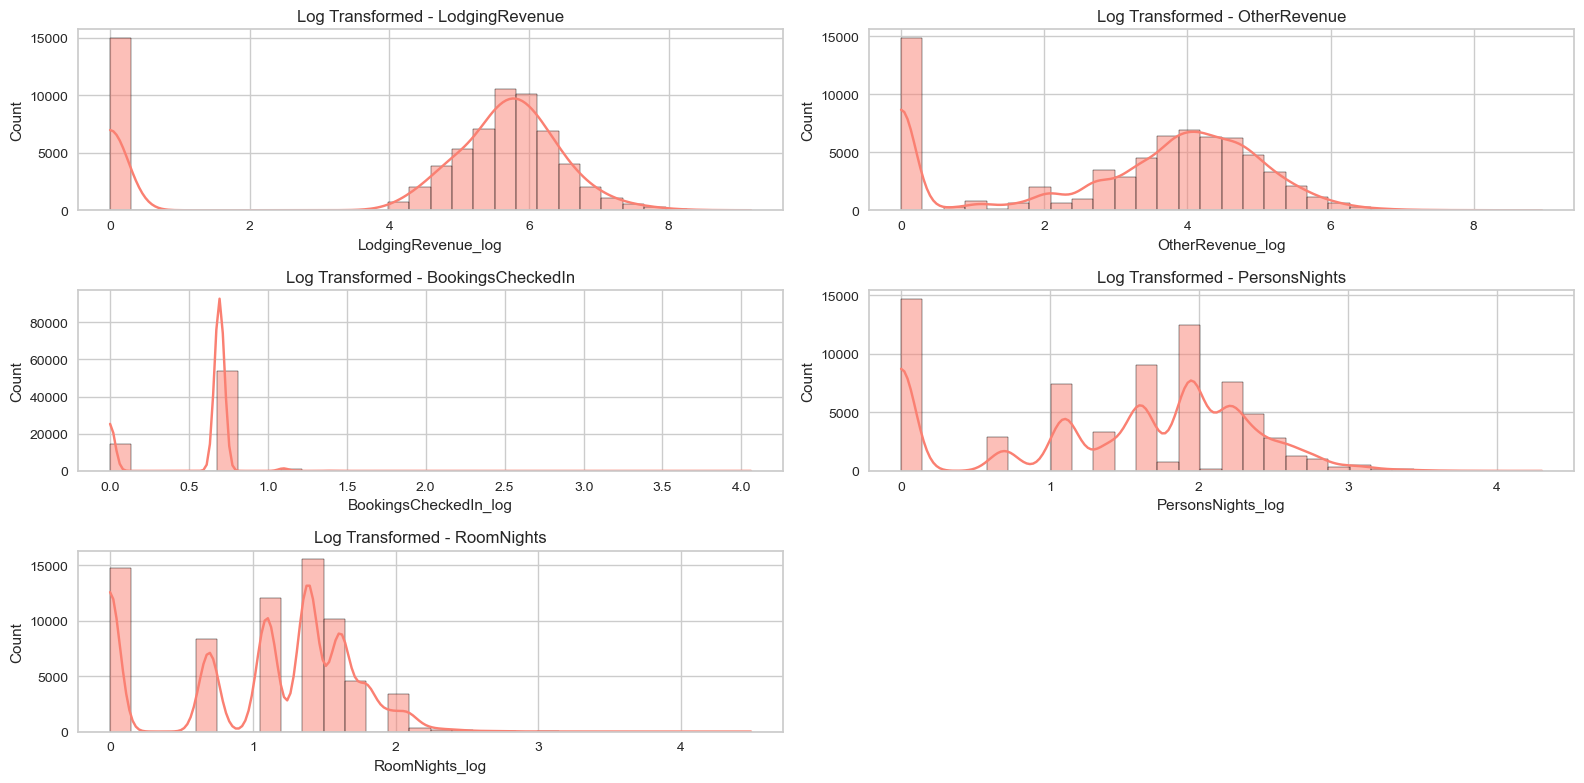

In [20]:
# List of variables to apply log transformation
log_vars = ['LodgingRevenue', 'OtherRevenue', 'BookingsCheckedIn', 'PersonsNights', 'RoomNights']

# Apply log transformation using log1p to handle zero values, and create new columns with "_log" suffix
for var in log_vars:
    df[var + '_log'] = np.log1p(df[var])  # log1p(x) = log(1 + x), safe for x = 0

# Define number of columns and calculate required number of rows for the subplot grid
n_cols = 2
n_rows = int(np.ceil(len(log_vars) / n_cols))  # Round up to ensure enough rows

# Set up figure size
plt.figure(figsize=(16, 8))

# Loop through variables and plot histograms with KDE for the log-transformed values
for i, var in enumerate(log_vars):
    plt.subplot(n_rows, n_cols, i + 1)  # Create subplot in the grid
    sns.histplot(df[var + '_log'], kde=True, bins=30, color='salmon')  # Histogram + KDE
    plt.title(f'Log Transformed - {var}')  # Add title to each subplot

# Adjust layout to avoid overlapping of plots
plt.tight_layout()
plt.show()

#### **Z-Score**
After the log transformation, it is evident that some variables exhibit distributions closer to normality, while others show a partially uniform distribution. However, since the log transformation has been applied, the Z-score can now be used.

In [21]:
# List of variables to calculate the Z-score for
zscore_vars = ['LodgingRevenue_log', 'OtherRevenue_log', 'BookingsCheckedIn_log', 'PersonsNights_log', 'RoomNights_log']

# Calculate the Z-scores for the selected variables
z_scores = df[zscore_vars].apply(zscore)

# Identify outliers: values with Z-scores greater than 3 or less than -3
outliers = (z_scores > 3) | (z_scores < -3)

# Remove the outliers by filtering them out of the dataset
df_no_outliers = df[~outliers.any(axis=1)]

# Check the shape of the dataset after removing outliers
df_no_outliers.shape

(69493, 36)

### Create variables
New variables were created based on existing columns in order to enrich the analysis and provide more informative metrics about customer behavior.

Additionally, using the variables `DaysSinceFirstStay` and `DaysSinceLastStay`, an indicator variable was created to reflect whether a customer has stayed at the hotel. Since around 18,000 customers have a value of `-1` in these fields (indicating they have never stayed at the hotel), the dataset was split into two distinct groups:
As a result, the dataset was split into two groups:

* **Active customers**: those who have stayed at the hotel and therefore have meaningful usage data.
* **Inactive customers**: those who never stayed and have no recorded usage of the hotel's services.

Since inactive customers have no behavioral data related to hotel stays, they were excluded from the main dataset to ensure the analysis focuses on relevant customer profiles.

**The active customers form the basis for clustering and behavioral profiling, while the inactive customers will be analyzed separately to investigate potential reasons for their lack of engagement with the hotel.**


In [22]:
# Customers who have already used the hotel
active_customers = df[(df['DaysSinceFirstStay'] != -1) & (df['DaysSinceLastStay'] != -1)]

# Number of active customers
print(f"Number of active customers: {len(active_customers)}")

Number of active customers: 54830


In [23]:
########################
### Create variables ###
########################

# 👩🧓 Age Group 
def age_group(age):
    if 13 <= age <= 19:
        return 'Teen'
    elif 20 <= age <= 39:
        return 'Adult'
    elif 40 <= age <= 59:
        return 'Middle Age Adult'
    elif age >= 60:
        return 'Senior' 

active_customers['Age_Group'] = active_customers['Age'].apply(age_group)

# 🕓 CustomerActivePeriod
# We calculate the customer's active period as the difference between the first and last stay.
# However, some customers only stayed once, which results in a 0-day active period.
# To avoid division by zero errors in derived metrics (e.g., AvgStaysPerYear),
# we replace 0-day periods with 1 day, as they stayed one night only at the hotel. This keeps these customers in the dataset
# without compromising calculations.
active_customers['CustomerActivePeriod'] = active_customers['DaysSinceFirstStay'] - active_customers['DaysSinceLastStay']
active_customers['CustomerActivePeriod'] = active_customers['CustomerActivePeriod'].replace(0, 1)

# 🛏️ AvgRoomNightsPerStay
active_customers['AvgRoomNightsPerStay'] = active_customers['RoomNights'] / active_customers['BookingsCheckedIn']

# 💰 TotalRevenue
active_customers['TotalRevenue'] = active_customers['LodgingRevenue'] + active_customers['OtherRevenue']

# 📊 AvgRevenuePerStay
active_customers['AvgRevenuePerStay'] = active_customers['TotalRevenue'] / active_customers['BookingsCheckedIn']

# 📆 AvgStaysPerYear
active_customers['AvgStaysPerYear'] = (active_customers['BookingsCheckedIn'] / active_customers['CustomerActivePeriod']) * 365

# 🍹 AvgOtherPerStay
active_customers['AvgOtherPerStay'] = active_customers['OtherRevenue'] / active_customers['BookingsCheckedIn']

# 📑 TotalReservationsMade
active_customers['TotalReservationsMade'] = (
    active_customers['BookingsCanceled'] +
    active_customers['BookingsNoShowed'] +
    active_customers['BookingsCheckedIn']
)

# ❌ CancelRate
active_customers['CancelRate'] = active_customers['BookingsCanceled'] / active_customers['TotalReservationsMade']

# 🚫 NoShowRate
active_customers['NoShowRate'] = active_customers['BookingsNoShowed'] / active_customers['TotalReservationsMade']

# ✅ ShowUpRate
active_customers['ShowUpRate'] = active_customers['BookingsCheckedIn'] / active_customers['TotalReservationsMade']

# 🧾 TotalSpecialRequests
# Convert boolean columns to int
bool_cols = [
    'SRHighFloor', 'SRLowFloor', 'SRAccessibleRoom', 'SRMediumFloor', 'SRBathtub',
    'SRShower', 'SRCrib', 'SRKingSizeBed', 'SRTwinBed', 'SRNearElevator',
    'SRAwayFromElevator', 'SRNoAlcoholInMiniBar', 'SRQuietRoom'
]
active_customers[bool_cols] = active_customers[bool_cols].astype(int)

active_customers['TotalSpecialRequests'] = active_customers[bool_cols].sum(axis=1)

# ✨ RequestedLuxury
active_customers['RequestedLuxury'] = (
    (active_customers['SRBathtub'] == 1) | (active_customers['SRKingSizeBed'] == 1)
).astype(int)

# ♿ RequestedAccessibility
active_customers['RequestedAccessibility'] = (
    (active_customers['SRAccessibleRoom'] == 1) | (active_customers['SRCrib'] == 1)
).astype(int)

# 🤫 WantsSilence
active_customers['WantsSilence'] = (
    (active_customers['SRQuietRoom'] == 1) | (active_customers['SRAwayFromElevator'] == 1)
).astype(int) 

In [24]:
# 🌎 Continent
def country_to_continent(alpha3_code):
    special_cases = {
        'ATA': 'Antarctica',
        'PCN': 'Oceania'}
    
    if alpha3_code in special_cases:
        return special_cases[alpha3_code]
    
    try:
        # Convert alpha-3 to alpha-2
        alpha2_code = pc.country_alpha3_to_country_alpha2(alpha3_code)
        # Get the continent's code
        continent_code = pc.country_alpha2_to_continent_code(alpha2_code)
        # Maps the continent code into name
        continent_dict = {
            'AF': 'Africa',
            'AS': 'Asia',
            'EU': 'Europe',
            'NA': 'North America',
            'SA': 'South America',
            'OC': 'Oceania',
            'AN': 'Antarctica'
        }
        return continent_dict.get(continent_code, 'Unknown')
    except Exception:
        return 'Unknown'

# AApply the function
active_customers['Continent'] = active_customers['Nationality'].apply(country_to_continent)
active_customers[['Nationality', 'Continent']].head()

,Nationality,Continent
3,FRA,Europe
5,JPN,Asia
7,FRA,Europe
9,IRL,Europe
11,FRA,Europe


---
### Data Visualization

#### 💶 **Spending and Booking Behavior by Age Group and Continent**

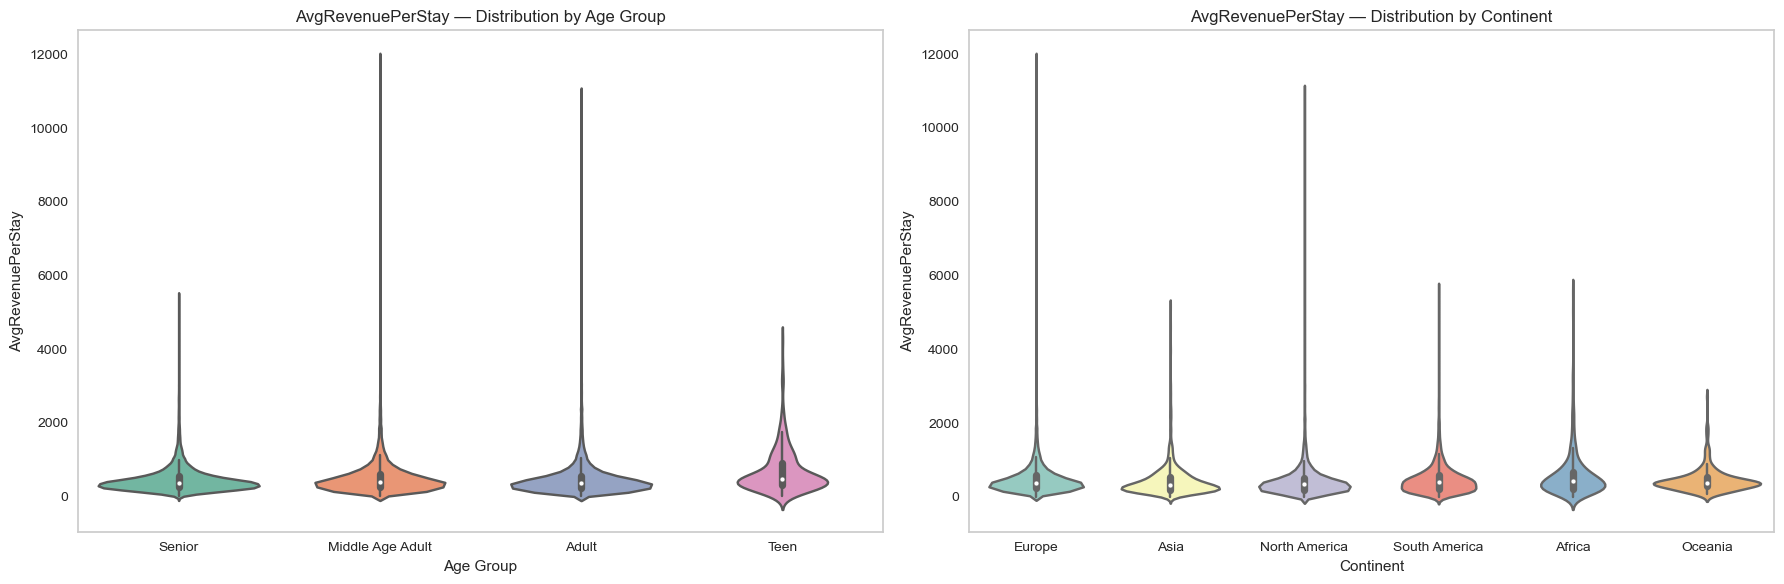

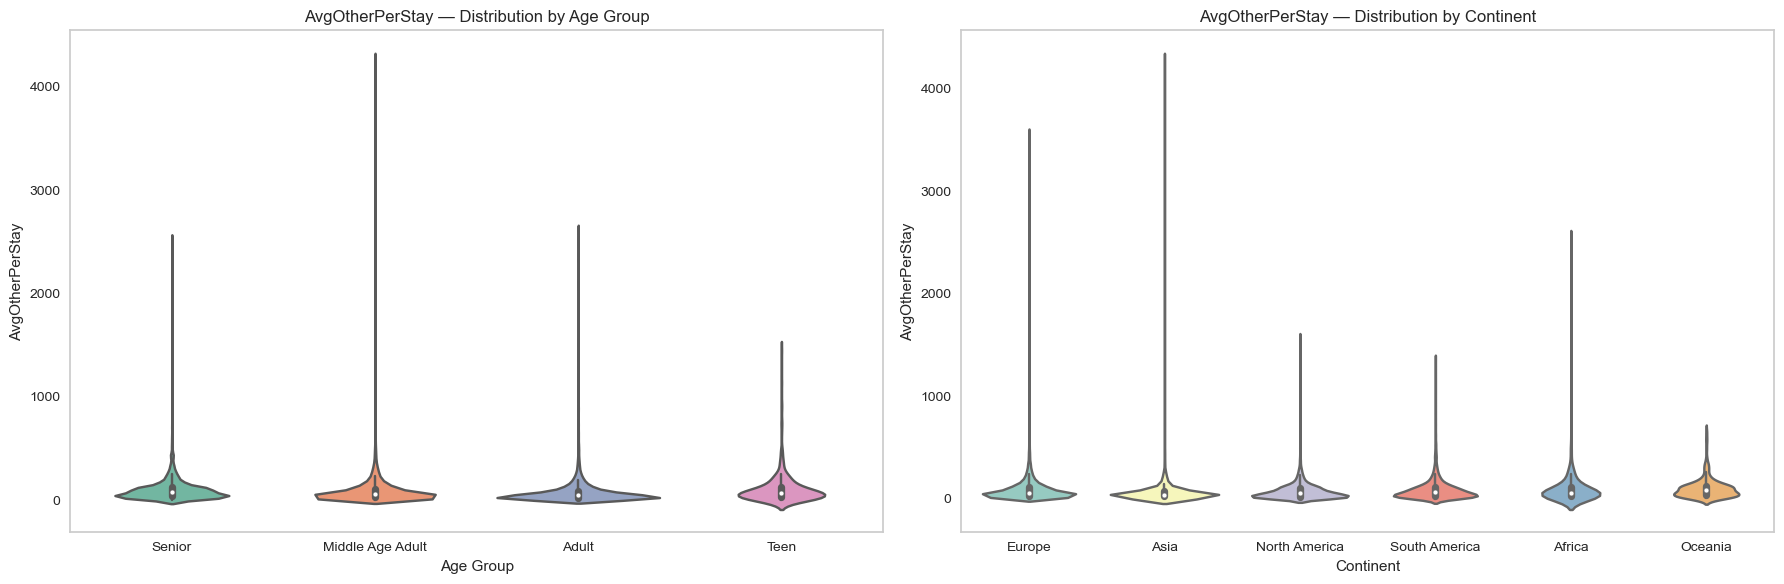

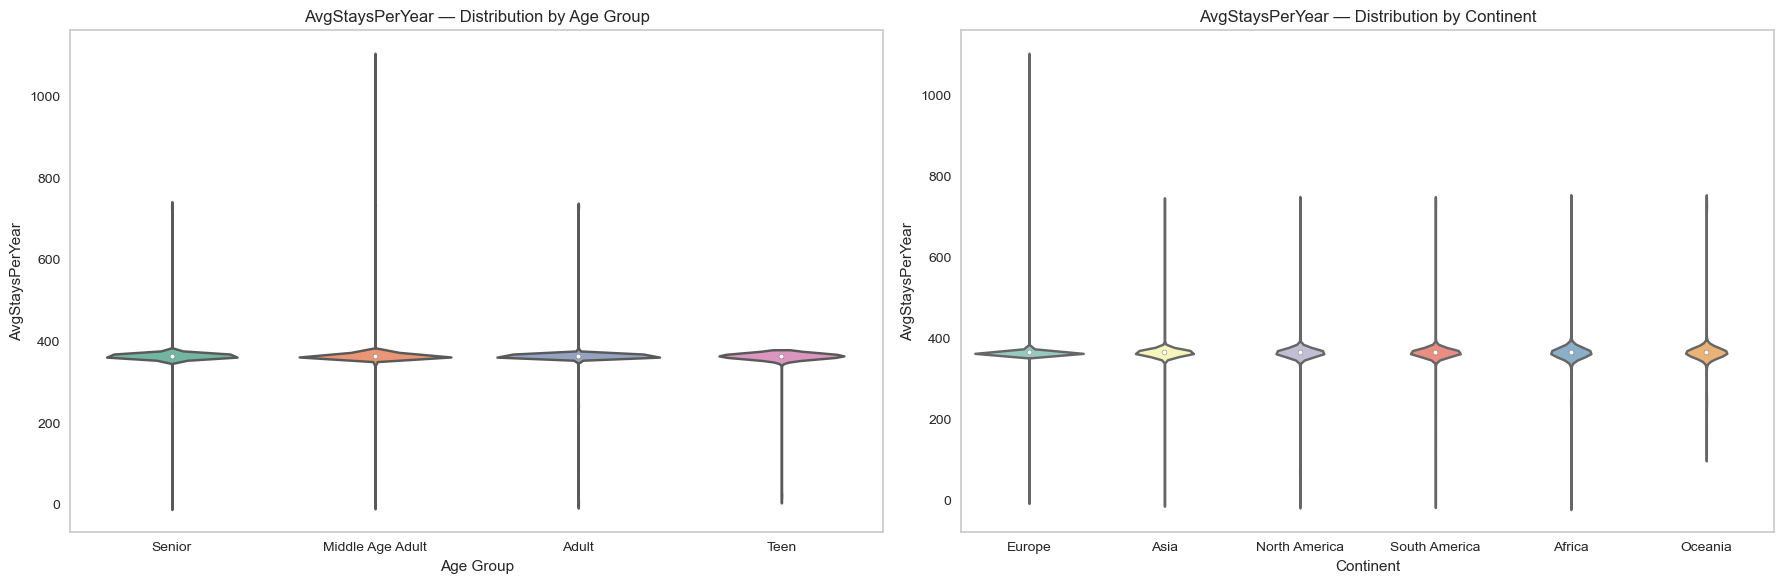

In [25]:
plt.rcParams['axes.grid'] = False

# Filter to remove 'Unknown' and 'Antarctica' from the continent, since there are only 5 records
filtered_data = active_customers[~active_customers['Continent'].isin(['Unknown', 'Antarctica'])]

# Color palettes for Age_Group and Continent
age_palette = sns.color_palette("Set2")
continent_palette = sns.color_palette("Set3")

gastos_vars = ['AvgRevenuePerStay', 'AvgOtherPerStay', 'AvgStaysPerYear']

for var in gastos_vars:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Violinplot for Age_Group
    sns.violinplot(
        data=filtered_data,
        x='Age_Group',
        y=var,
        palette=age_palette,
        ax=axes[0]
    )
    axes[0].set_title(f'{var} — Distribution by Age Group')
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel(var)

    # Violinplot for Continent
    sns.violinplot(
        data=filtered_data,
        x='Continent',
        y=var,
        palette=continent_palette,
        ax=axes[1]
    )
    axes[1].set_title(f'{var} — Distribution by Continent')
    axes[1].set_xlabel('Continent')
    axes[1].set_ylabel(var)

    plt.tight_layout()
    plt.show() 

##### Spending and Booking Behavior by Age Group and Continent - Analysis
In terms of `AvgRevenuePerStay` and `AvgOtherPerStay`, the majority of customers tend to have **low spending per stay**, with only a few **high-spending outliers** observed across all age groups and continents. A slightly higher concentration of **moderate spending** is observed among `Adult` and `Middle Age Adult` customers, while customers from `Europe` and `North America` show slightly higher peaks in spending compared to other regions. 
For `AvgStaysPerYear`, the patterns are notably more **uniform**. Across both age groups and continents, most customers cluster around **400 stays annually**, with minimal variation and few outliers. This suggests that the **frequency of bookings** is relatively stable and not strongly influenced by demographic factors. 
In general, although there are slight variations between groups, neither **continent** nor **age** appears to be a strong predictor of spending or booking behavior. The presence of high-spending outliers across segments indicates that further investigation of other behavioral variables is necessary to develop more precise customer segments.

In [26]:
# Show descriptive statistics
active_customers[['TotalReservationsMade','CancelRate', 'NoShowRate', 'ShowUpRate']].describe().round(3).transpose() 

,count,mean,std,min,25%,50%,75%,max
TotalReservationsMade,54830.0,1.023,0.373,1.000,1.0,1.0,1.0,66.000
CancelRate,54830.0,0.000,0.008,0.000,0.0,0.0,0.0,0.500
NoShowRate,54830.0,0.000,0.005,0.000,0.0,0.0,0.0,0.667
ShowUpRate,54830.0,1.000,0.010,0.333,1.0,1.0,1.0,1.000


#### 🛏️ **Stay/Travel Behavior by Age Group and Continent** 

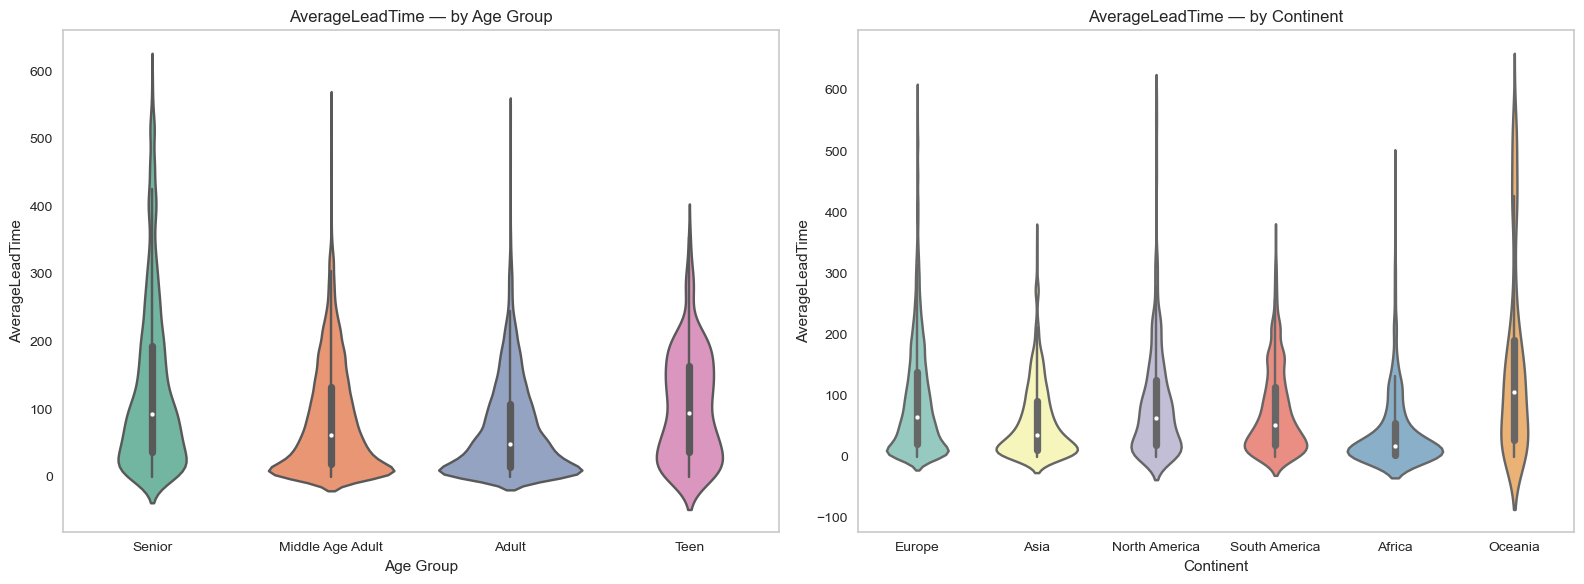

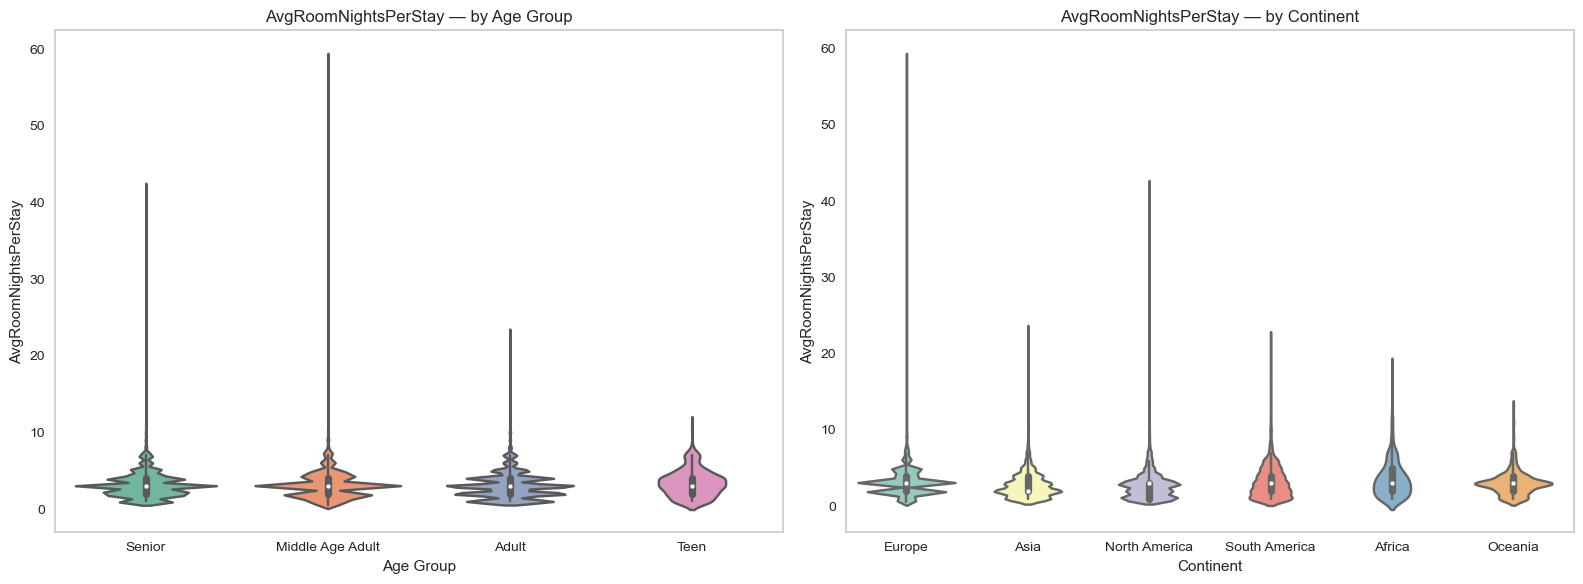

In [27]:
# Variables related to stay behavior
stay_vars = ['AverageLeadTime', 'AvgRoomNightsPerStay']

# Plot violin plots side by side
for var in stay_vars:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Violin plot by Age Group
    sns.violinplot(
        data=filtered_data,
        x='Age_Group',
        y=var,
        palette=age_palette,
        ax=axes[0]
    )
    axes[0].set_title(f'{var} — by Age Group')
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel(var)

    # Violin plot by Continent
    sns.violinplot(
        data=filtered_data,
        x='Continent',
        y=var,
        palette=continent_palette,
        ax=axes[1]
    )
    axes[1].set_title(f'{var} — by Continent')
    axes[1].set_xlabel('Continent')
    axes[1].set_ylabel(var)

    plt.tight_layout()
    plt.show()

##### Travel Behavior by Age Group and Continent - Analysis
`AverageLeadTime` by age group shows that most customers tend to **book with shorter notice**, with the highest concentration in the `Adult` and `Middle-Aged Adult` categories. However, both the `Senior` and `Teen` groups display a **wider spread of lead times**, ranging from around 10 to 300 days, indicating more **varied booking behaviors**.

By continent, there are no major differences, **except for Oceania**, which stands out for having **higher and more dispersed AverageLeadTime values**, with a relatively uniform distribution. This contrasts with other continents, where bookings are more **concentrated around shorter time frames**.

Regarding `AvgRoomNightsPerStay`, a **consistent pattern** is observed across both age groups and continents — most customers tend to **stay for short periods**. Nevertheless, there is a **higher occurrence of longer stays** among `Middle-Aged Adults` and `Seniors`. Geographically, although the differences are minor, there is a similar trend toward **longer stays** in `Europe` and `North America`.

Overall, **age** and **continent** do not appear to be strong determinants of either `AverageLeadTime` or `AvgRoomNightsPerStay`. Moreover, the previous presence of outliers, such as negative lead times, highlights the importance of ongoing data validation and exploring additional variables to better understand customer behavior.

#### 🛎️ **Special Requests and Preferences** 

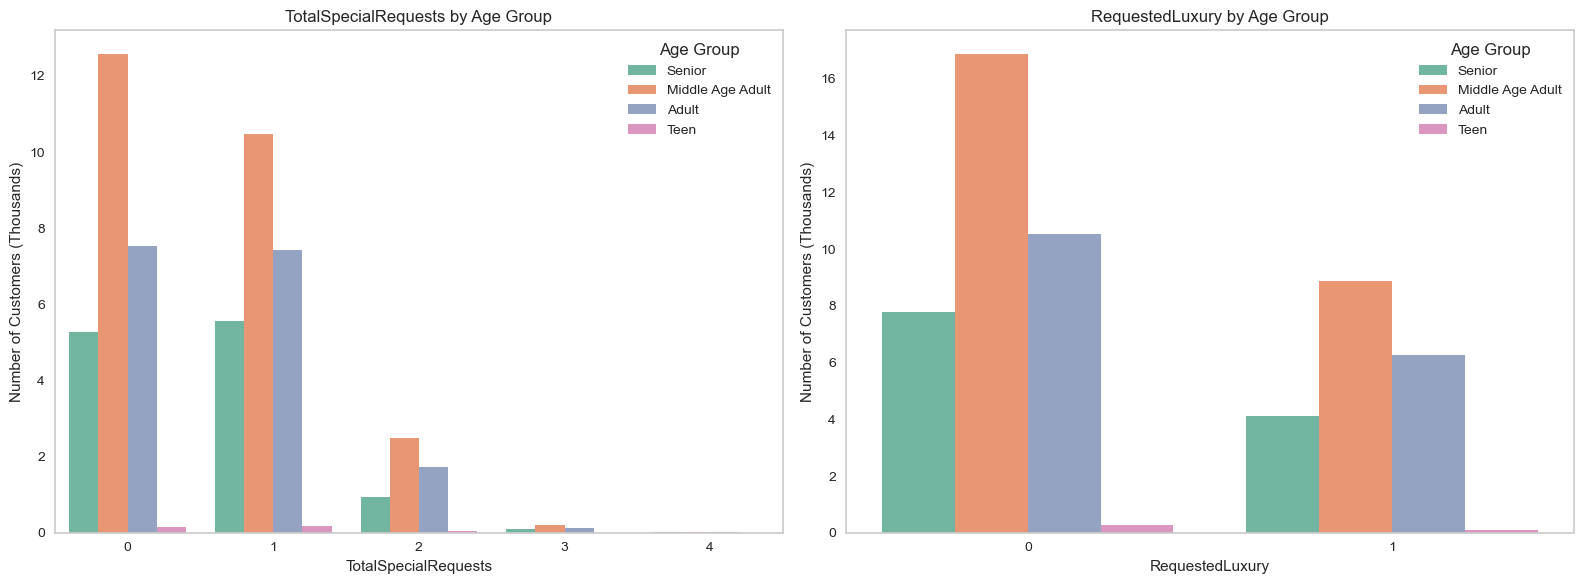

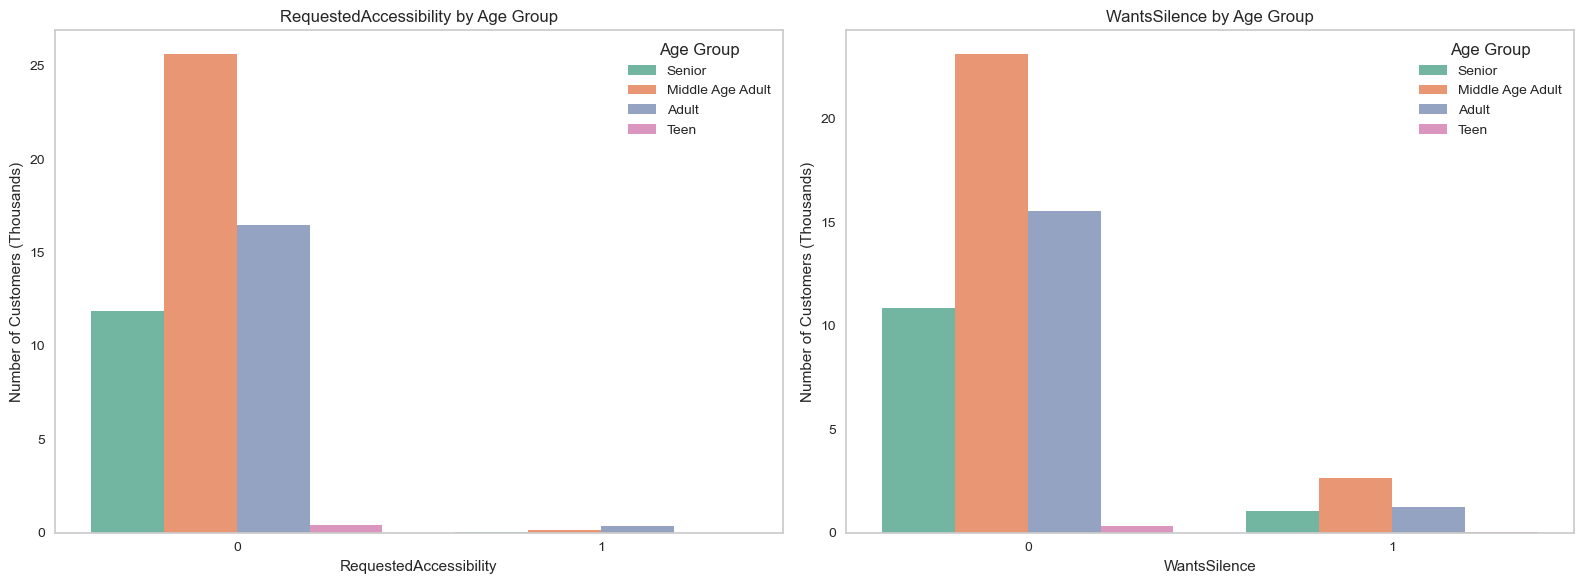

In [28]:
# Define variables related to customer preferences
preference_vars = ['TotalSpecialRequests', 'RequestedLuxury', 'RequestedAccessibility', 'WantsSilence']

# Plot countplots in pairs, with hue by Age_Group and y-axis divided by 1000
for i in range(0, len(preference_vars), 2):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for j, var in enumerate(preference_vars[i:i+2]):
        sns.countplot(
            data=active_customers,
            x=var,
            hue='Age_Group',
            palette='Set2',
            ax=axes[j]
        )
        axes[j].set_title(f'{var} by Age Group')
        axes[j].set_xlabel(var)
        axes[j].set_ylabel('Number of Customers (Thousands)')
        
        # Adjust y-axis tick labels to show in thousands
        yticks = axes[j].get_yticks()
        axes[j].set_yticklabels([f'{int(y/1000)}' if y != 0 else '0' for y in yticks])
        
        axes[j].legend(title='Age Group')
    
    plt.tight_layout()
    plt.show() 

##### Special Requests and Preferences - Analysis
Most customers (in all age groups) tend to **not make special requests**, like `RequestedAccessibility`, `RequestedLuxury`, or `WantsSilence`. However, among the ones who make requests, `Middle Age Adult` and `Adult` categories show **higher predominance** compared to the other age groups, with `Middle Age Adult` having the highest number of requests both made and not made. It is important to note that `RequestedAccessibility` is by far the **lowest category requested**. 
Overall, while the data suggests a tendency for certain age groups (`Middle-Aged Adults` and `Adults`) to make more special requests, the **majority of customers** across all groups do **not make requests**. Indicating that these patterns in special requests are **not a primary driver** of customer behavior and should be complemented by other variables in customer segmentation efforts.

#### **🌍 Demographic / Geographic Profile**

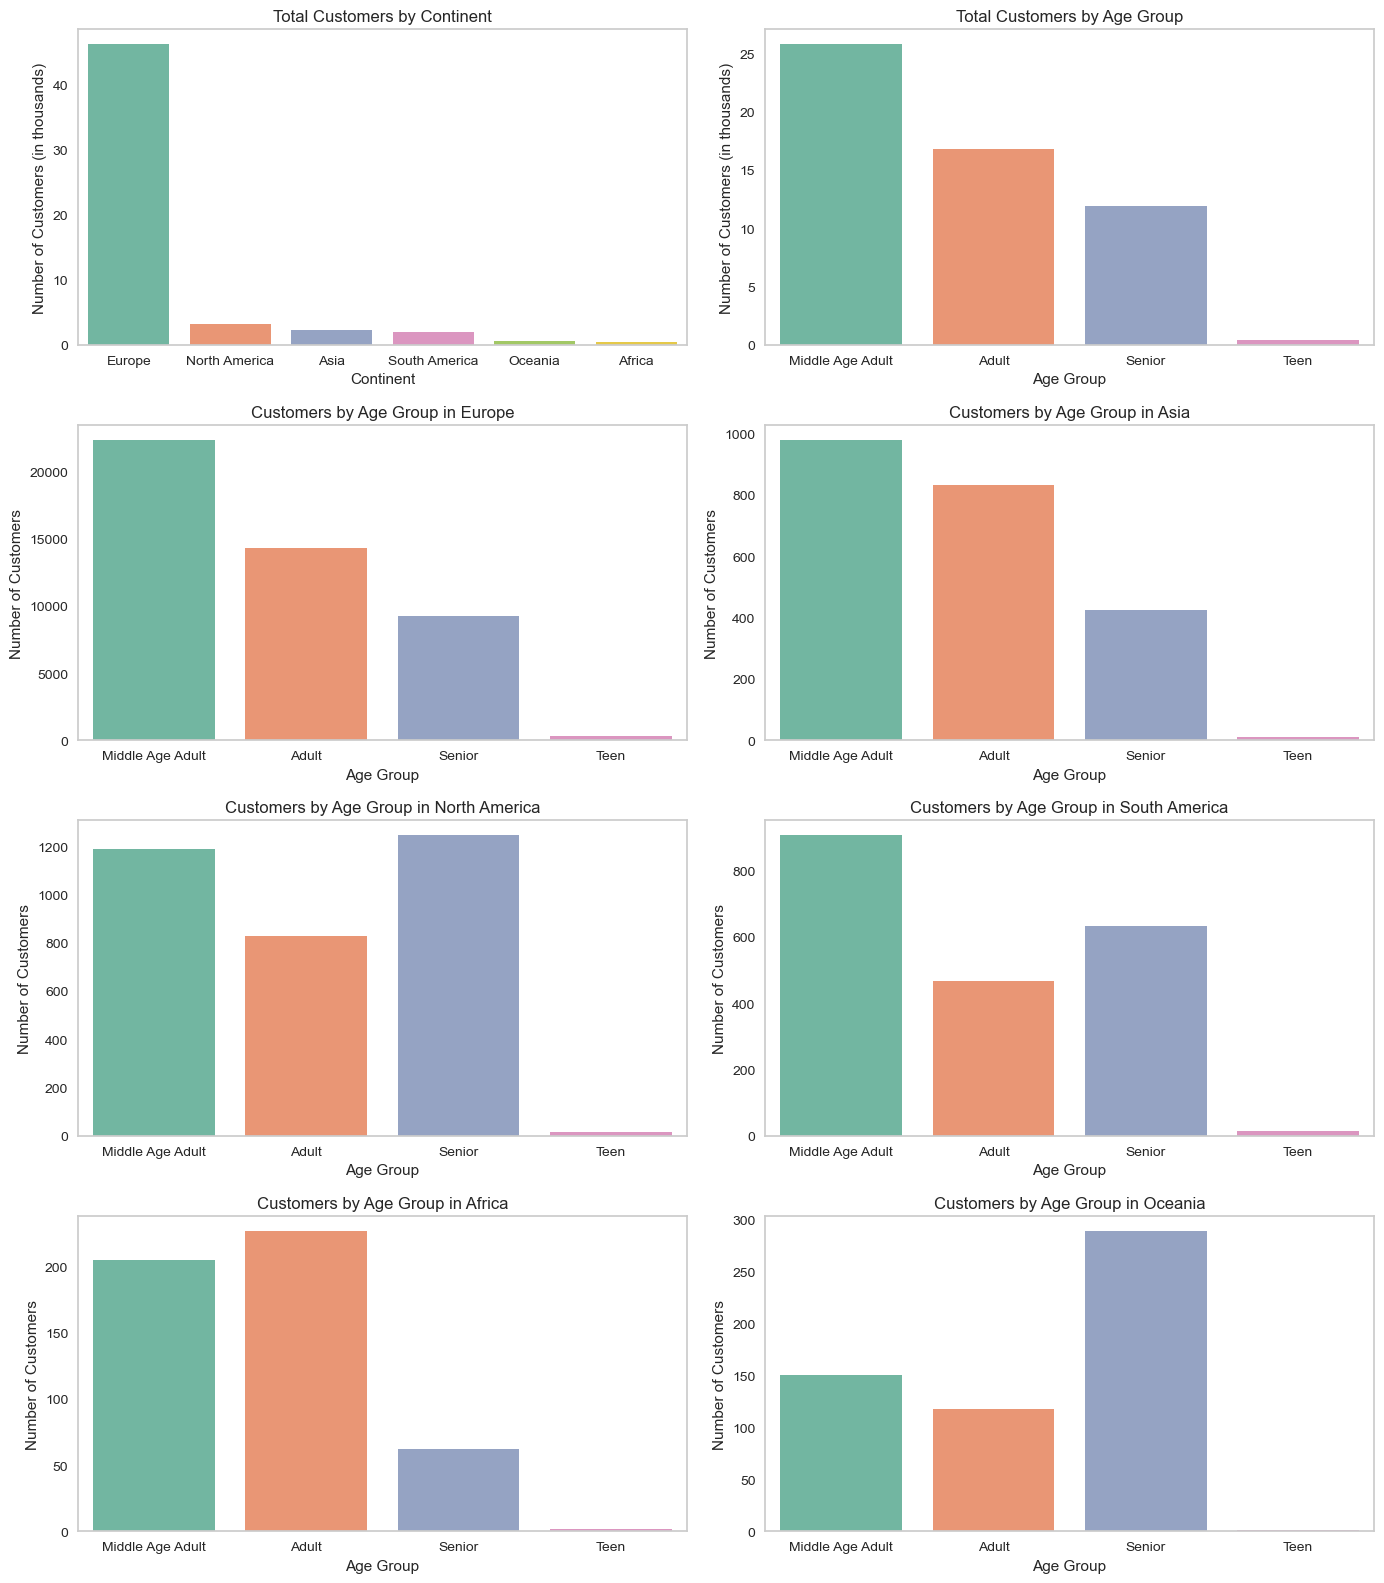

In [29]:
# Get the list of unique continents
continents = filtered_data['Continent'].unique()

# Total number of plots (2 summary + 1 per continent)
n_total_plots = len(continents) + 2

# Define number of subplot columns and rows
n_cols = 2
n_rows = int(np.ceil(n_total_plots / n_cols))

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

# Plot 1: Total customers by continent
sns.countplot(
    data=filtered_data,
    x='Continent',
    order=filtered_data['Continent'].value_counts().index,
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Total Customers by Continent')
axes[0].set_xlabel('Continent')
axes[0].set_ylabel('Number of Customers (in thousands)')
axes[0].tick_params(axis='x')

# Adjust Y axis to show in thousands
y_labels = axes[0].get_yticks()
axes[0].set_yticklabels([f'{int(label/1000)}' for label in y_labels])

# Plot 2: Total customers by Age Group
sns.countplot(
    data=filtered_data,
    x='Age_Group',
    order=filtered_data['Age_Group'].value_counts().index,
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Total Customers by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Customers (in thousands)')
axes[1].tick_params(axis='x')

# Adjust Y axis to show in thousands
y_labels = axes[1].get_yticks()
axes[1].set_yticklabels([f'{int(label/1000)}' for label in y_labels])

# Plots for each continent by Age Group
for i, continent in enumerate(continents):
    ax = axes[i + 2]  # Start from index 2
    subset = filtered_data[filtered_data['Continent'] == continent]

    sns.countplot(
        data=subset,
        x='Age_Group',
        order=filtered_data['Age_Group'].value_counts().index,
        palette='Set2',
        ax=ax
    )
    ax.set_title(f'Customers by Age Group in {continent}')
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Number of Customers')
    ax.tick_params(axis='x')

# Remove unused subplots
for j in range(n_total_plots, len(axes)):
    fig.delaxes(axes[j])

# Final layout adjustment
plt.tight_layout()
plt.show()

##### Customer distribution by continent and age group - Analysis

As previously observed in the descriptive statistics, the **majority of customers are from Europe**, and the graph above confirms that most of them fall within the `Middle-Aged Adult` group. On the other hand, all other continents show a **significantly smaller customer base**, with the `Teen` age group being the **least represented** across the entire dataset.

In **South America**, the `Middle-Aged Adult` group is also the most prominent, a pattern similarly observed in **Asia**, although in Asia the difference with the `Adult` group is less pronounced. In both **North America** and **Oceania**, the `Senior` group stands out more clearly — especially in Oceania, while in North America there is a more balanced presence between `Senior` and `Middle-Aged Adult`.

Finally, in **Africa**, the most represented group is the `Adult` segment. 

### Correlations

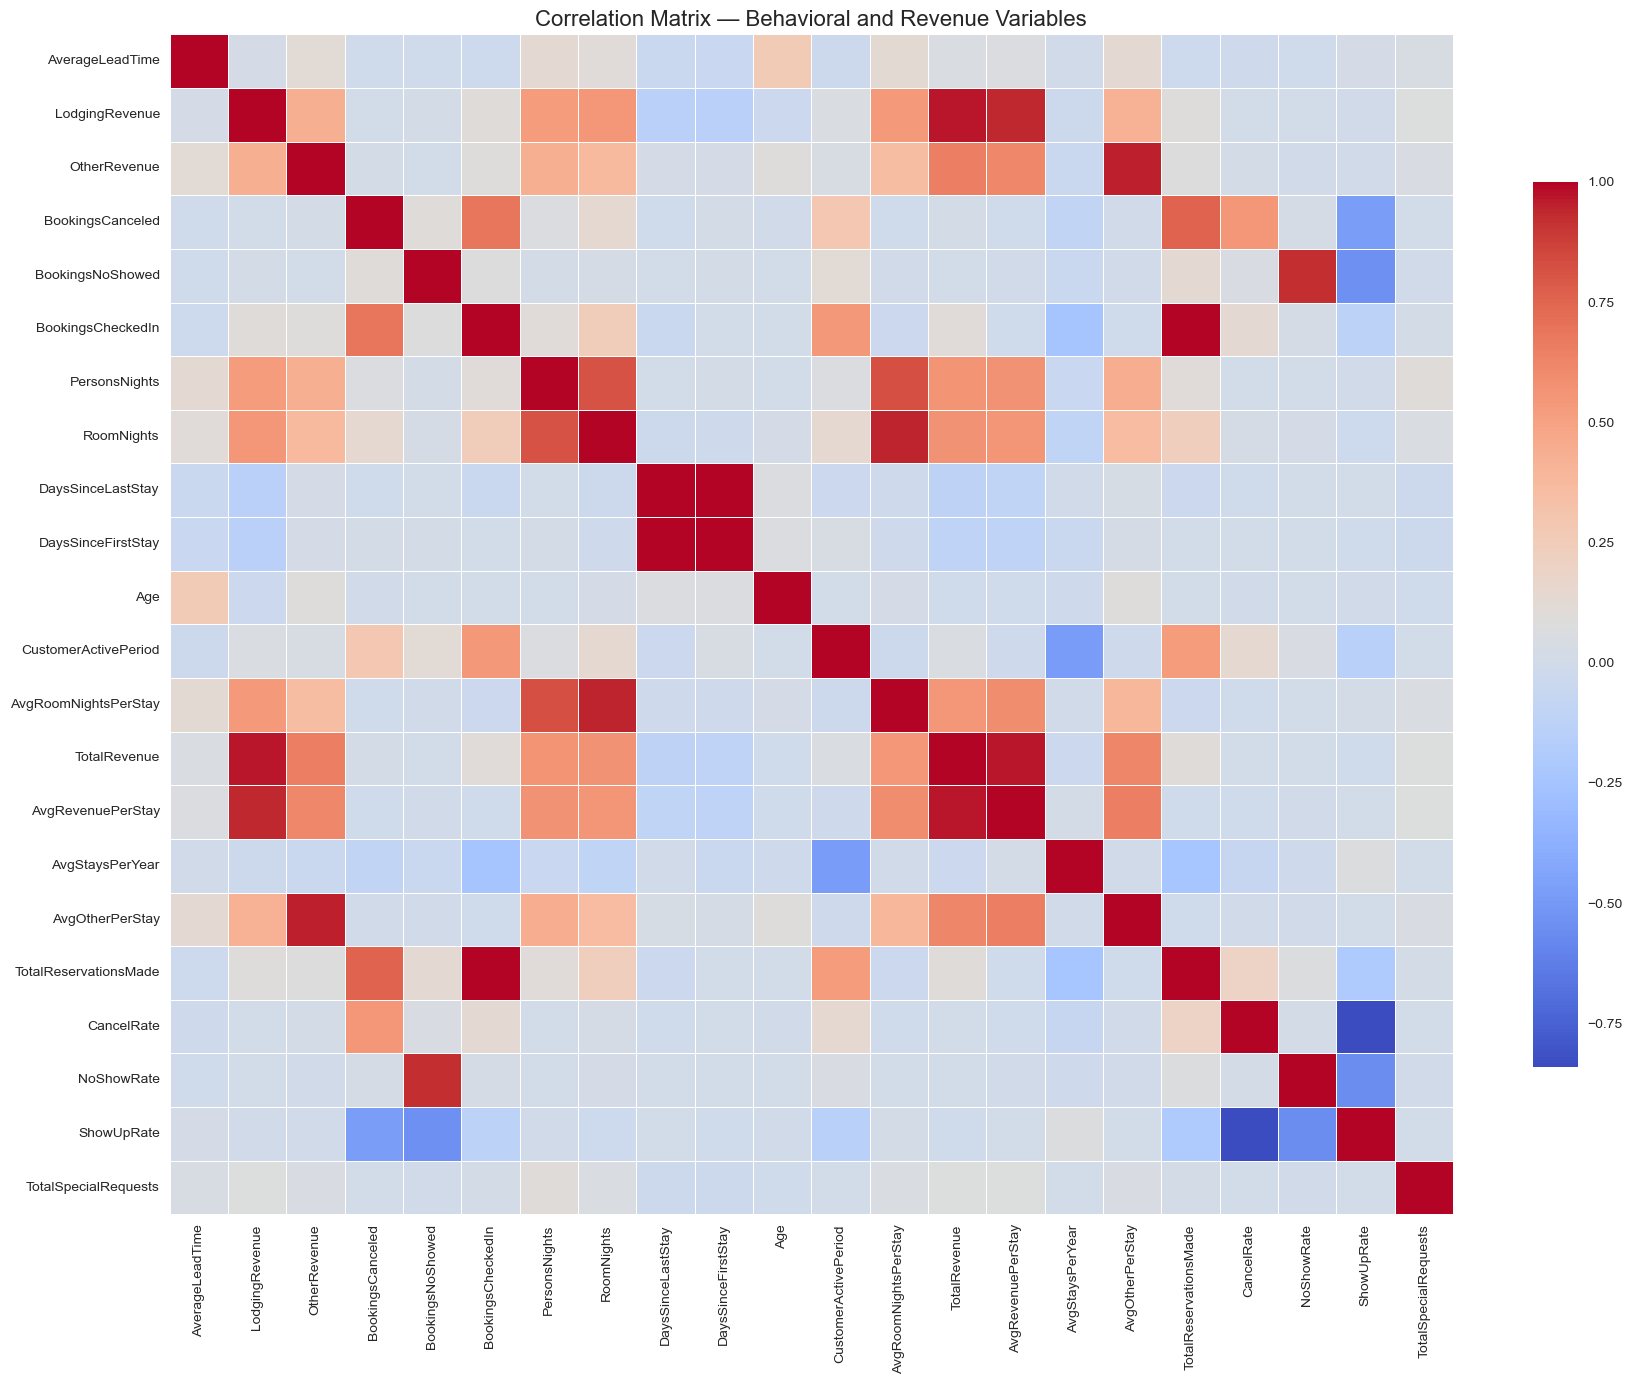

In [30]:
# Select the relevant behavioral and revenue-related variables
selected_vars = [
    'AverageLeadTime', 'LodgingRevenue', 'OtherRevenue',
    'BookingsCanceled', 'BookingsNoShowed', 'BookingsCheckedIn',
    'PersonsNights', 'RoomNights', 'DaysSinceLastStay',
    'DaysSinceFirstStay', 'Age', 'CustomerActivePeriod', 'AvgRoomNightsPerStay',
    'TotalRevenue', 'AvgRevenuePerStay', 'AvgStaysPerYear',
    'AvgOtherPerStay', 'TotalReservationsMade', 'CancelRate', 'NoShowRate',
    'ShowUpRate', 'TotalSpecialRequests']

# Filter the dataset with only active customers and selected variables
behavioral_data = active_customers[selected_vars]

# Compute the correlation matrix
corr_matrix = behavioral_data.corr()

# Plot the heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.5,
    square=False,
    cbar_kws={"shrink": .75}
)
plt.title('Correlation Matrix — Behavioral and Revenue Variables', fontsize=16)
plt.tight_layout()
plt.show() 

##### Correlation Analysis — Behavioral and Revenue Variables
The correlation matrix reveals several **strong patterns**. **Revenue variables** -  `TotalRevenue`, `AvgRevenuePerStay`, `AvgOtherPerStay`, and `TotalReservationsMade`- show **strong positive correlations**, suggesting that customers who **spend more per stay** and **book more frequently** contribute more to overall revenue. 
Similarly, **strong correlations** are also seen among **behavioral metrics** like `RoomNights`, `PersonNights`, and `BookingsCheckedIn`, reflecting the **expected connection** between booking activity and length of stay. 
In contrast, there are apparent negative correlations between `CancelRate`and `NoShowRate` with **revenue variables**, indicating that **cancellations and no shows reduce revenue**. 
**Demographic variables** such as `Age` and `CustomerActivePeriod` show **weak correlations**, suggesting they are less useful for predicting spending behavior.
Overall, the results suggest that **behavioral and transactional variables** related to **bookings and spending** are the most relevant for **understanding customer behavior and revenue prediction**. These should be prioritized in segmentation and modeling processes.

### Variables Selection for Clustering

Based on the analyses performed above and the correlation results, the variables selected for the clustering phase were: 'Age', 'AverageLeadTime', 'BookingsCheckedIn', 'TotalSpecialRequests', 'CustomerActivePeriod', 'LodgingRevenue', 'OtherRevenue', 'RequestedLuxury', 'RequestedAccessibility', and 'WantsSilence'.

In [31]:
# List of variables for clustering
vars_clustering = [
    'Age',
    'AverageLeadTime', 
    'BookingsCheckedIn',
    'TotalSpecialRequests',
    'CustomerActivePeriod',
    'LodgingRevenue',
    'OtherRevenue',
    'RequestedLuxury',
    'RequestedAccessibility',
    'WantsSilence',
    'Continent'
]

# Select only columns for clustering
data_clustering = active_customers[vars_clustering].copy()
data_clustering.head()

,Age,AverageLeadTime,BookingsCheckedIn,TotalSpecialRequests,CustomerActivePeriod,LodgingRevenue,OtherRevenue,RequestedLuxury,RequestedAccessibility,WantsSilence,Continent
3,60.0,93,1,0,1,240.0,60.0,0,0,0,Europe
5,54.0,58,1,0,1,230.0,24.0,0,0,0,Asia
7,32.0,38,1,1,1,535.0,94.0,1,0,0,Europe
9,25.0,96,1,0,1,174.0,69.0,0,0,0,Europe
11,58.0,60,1,0,1,292.0,81.0,0,0,0,Europe


Given the insights gathered from the exploratory data analysis and the correlation matrix, the modeling phase will proceed with a clustering approach to identify distinct customer profiles based on behavioral and transactional patterns.

To capture potentially different dynamics across customer segments, **two separate clustering models** will be developed:

1. **Cluster analysis for European customers** – Since the majority of customers in the dataset are from Europe (about 84.3%), this dedicated clustering will help uncover finer-grained patterns specific to this dominant group.

2. **Cluster analysis for non-European customers** – A second model will be applied to customers from all other continents. This ensures that minority groups are not overshadowed by the volume of European data and allows us to explore whether different behavioral trends emerge outside of Europe.

This two-pronged approach allows for a more tailored and balanced segmentation strategy that acknowledges the geographical skew in the dataset while ensuring meaningful insights across all customer types.


In [32]:
# Split dataset into European and non-European customers
europe_customers = data_clustering[data_clustering['Continent'] == 'Europe'].copy()
non_europe_customers = data_clustering[data_clustering['Continent'] != 'Europe'].copy() 

### Normalization

Considering that the variables have different scales, the variables were standardized to ensure comparability.

In [33]:
## Get a copy of the dataframes before normalization for results' analysis

# Drop 'Continent' column before normalization (not used in clustering) 
europe_customers = europe_customers.drop(columns=['Continent'])
europe_customersbeforeNORM = europe_customers.copy(deep=True)

non_europe_customers = non_europe_customers.drop(columns=['Continent'])
non_europe_customersbeforeNORM = non_europe_customers.copy(deep=True)

# Normalize each subset separately using MinMaxScaler
# MinMax scaler returns an array, so the dataframe must be recreated
scaler = preprocessing.MinMaxScaler()

europe_customers_normalized = pd.DataFrame(
    scaler.fit_transform(europe_customers),
    columns=europe_customers.columns,
    index=europe_customers.index
)

non_europe_customers_normalized = pd.DataFrame(
    scaler.fit_transform(non_europe_customers),
    columns=non_europe_customers.columns,
    index=non_europe_customers.index
)

---
## 👩🏾👨‍🦰🏨 Modeling - K-Means  

#### **Elbow method**

The **Elbow Method** is a widely used technique for determining the optimal value of *k* in K-Means clustering. It works by computing the Within-Cluster Sum of Squares (WCSS) for different values of *k*, which measures how closely the data points are grouped around their respective centroids. A lower WCSS indicates tighter clusters. The "elbow" point on the graph marks where increasing *k* yields diminishing returns in reducing WCSS, thereby helping to identify the most appropriate number of clusters.

Based on the plots shown below, the **optimal number of clusters is 3** for both datasets.


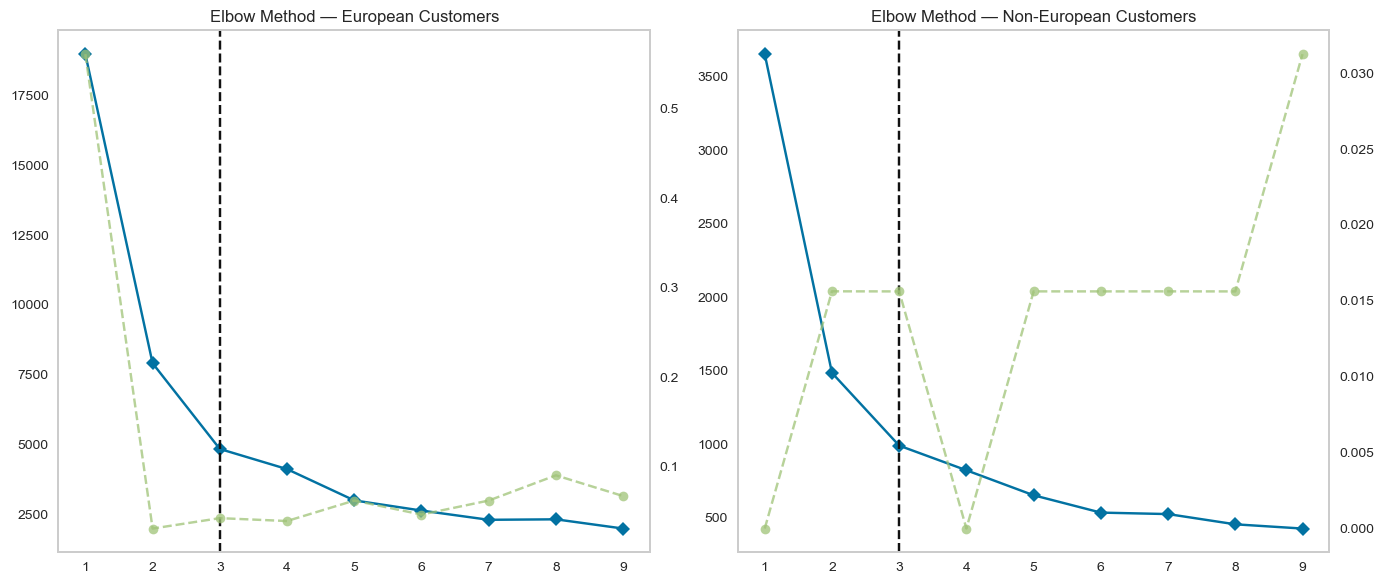

In [34]:
# Set up subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Elbow for European customers
km_europe = KMeans(random_state=50)
visualizer_europe = KElbowVisualizer(km_europe, k=(1, 10), ax=axes[0])
visualizer_europe.fit(europe_customers_normalized)
axes[0].set_title("Elbow Method — European Customers")

# Elbow for Non-European customers
km_non_europe = KMeans(random_state=50)
visualizer_non_europe = KElbowVisualizer(km_non_europe, k=(1, 10), ax=axes[1])
visualizer_non_europe.fit(non_europe_customers_normalized)
axes[1].set_title("Elbow Method — Non-European Customers")

plt.tight_layout()
plt.show()

#### **Silhouette Score**

The Silhouette plots above provide a visual assessment of how well each observation lies within its cluster. The silhouette score ranges from -1 to 1, where values closer to 1 indicate well-clustered observations, values near 0 suggest overlapping clusters, and negative values may indicate misclassified data points.

For both **European** and **Non-European** customers:

* The **average silhouette score** is slightly above **0.6**, which indicates **good overall clustering quality**. Most customers are well assigned to their respective clusters, with clear separation between groups.
* The **widths of the clusters** in the plot (represented by different colors) show relatively balanced group sizes, particularly in the Non-European segment.
* There are **no significant signs of misclassification**, as there are very few (if any) points with negative silhouette values.

In conclusion, a silhouette score above 0.6 suggests that the clustering configuration (with **k = 3**) provides a **robust and meaningful segmentation**, reinforcing the results obtained through the Elbow Method.

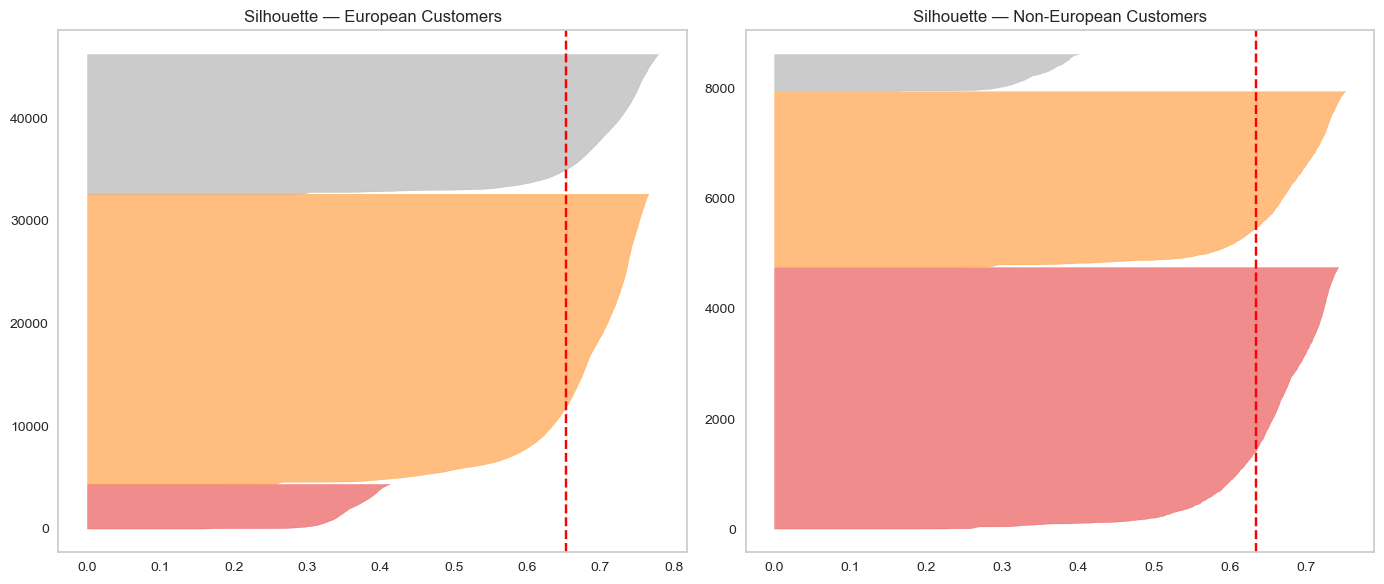

In [35]:
# Define figure for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Silhouette plot for European customers
kmeans_europe = KMeans(n_clusters=3, random_state=50)  
visualizer_europe = SilhouetteVisualizer(kmeans_europe, ax=axes[0])
visualizer_europe.fit(europe_customers_normalized)
axes[0].set_title("Silhouette — European Customers")

# Silhouette plot for Non-European customers
kmeans_non_europe = KMeans(n_clusters=3, random_state=50)   
visualizer_non_europe = SilhouetteVisualizer(kmeans_non_europe, ax=axes[1])
visualizer_non_europe.fit(non_europe_customers_normalized)
axes[1].set_title("Silhouette — Non-European Customers")

plt.tight_layout()
plt.show()

#### **K-Means - European Customers**

In [36]:
# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=50)
kmeans.fit(europe_customers_normalized)  # data_clustering is your normalized dataset

# Assign the cluster labels to the original (non-normalized) dataset
europe_customersbeforeNORM['Cluster'] = kmeans.labels_ 

# Number of customers per cluster
print(europe_customersbeforeNORM['Cluster'].value_counts())

# Mean statistics per cluster (useful for profiling)
cluster_profiles = europe_customersbeforeNORM.groupby('Cluster').mean(numeric_only=True).round(2)
cluster_profiles

Cluster
1    28283
2    13605
0     4343
Name: count, dtype: int64


,Age,AverageLeadTime,BookingsCheckedIn,TotalSpecialRequests,CustomerActivePeriod,LodgingRevenue,OtherRevenue,RequestedLuxury,RequestedAccessibility,WantsSilence
Cluster,,,,,,,,,,
0,48.19,95.23,1.02,1.79,1.51,486.61,102.30,0.52,0.01,1.0
1,47.66,94.33,1.02,0.23,2.05,382.99,88.65,0.00,0.01,0.0
2,46.37,89.35,1.03,1.11,3.27,403.75,94.87,1.00,0.01,0.0


#### **Segment Profile**

**Cluster 0 – Demanding, comfort-oriented customers 🛎️**

Book well in advance (95 days), spend more, make several special requests, and prefer quiet environments. Over half request luxury services. This profile seeks maximum comfort and a personalized, exclusive experience during their stay.

**Cluster 1 – Practical, low-demand customers 🎒**

Book with similar lead time, spend less, make few special requests, and do not value luxury or quietness. These customers have simple expectations, focusing on functional solutions and cost-effectiveness.

**Cluster 2 – Loyal customers with a taste for luxury 💎**

Have the longest loyalty period, make moderate requests, all prefer luxury but do not value quietness. They spend average amounts. They maintain a steady relationship with the hotel, showing potential for loyalty programs and exclusive offers.


#### **K-Means - Non-European Customers**

In [37]:
# Apply K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=50)
kmeans.fit(non_europe_customers_normalized)  # data_clustering is your normalized dataset

# Assign the cluster labels to the original (non-normalized) dataset
non_europe_customersbeforeNORM['Cluster'] = kmeans.labels_ 

# Number of customers per cluster
print(non_europe_customersbeforeNORM['Cluster'].value_counts())

# Mean statistics per cluster (useful for profiling)
cluster_profiles = non_europe_customersbeforeNORM.groupby('Cluster').mean(numeric_only=True).round(2)
cluster_profiles

Cluster
0    4749
1    3185
2     665
Name: count, dtype: int64


,Age,AverageLeadTime,BookingsCheckedIn,TotalSpecialRequests,CustomerActivePeriod,LodgingRevenue,OtherRevenue,RequestedLuxury,RequestedAccessibility,WantsSilence
Cluster,,,,,,,,,,
0,49.66,75.00,1.03,0.29,1.65,384.85,76.48,0.00,0.01,0.0
1,50.74,83.90,1.03,1.09,1.44,375.29,81.00,1.00,0.01,0.0
2,51.36,76.44,1.03,1.88,1.86,469.56,82.13,0.51,0.01,1.0


#### **Segment Profile**

**Cluster 0 – Practical, low-demand customers 🎒**

Book with the shortest lead time (75 days), spend less, make few requests, and do not value luxury or quietness. These customers focus on practicality and economy, with basic needs.

**Cluster 1 – Customers who book with the longest lead time ⏳**

This is the non-European group that books with the longest lead time (84 days), make moderate requests, and all prefer luxury services, although they do not value quiet environments. They spend slightly less, seeking comfort and quality but without prioritizing tranquility.

**Cluster 2 – Customers who spend more and make more requests 💎**

Have the highest revenue and the most special requests. About half request luxury services, and nearly all value quiet environments. These customers prioritize comfort and tranquility, willing to invest more for it. 

---
### **Marketing Strategies** 🎯

We suggest two specific marketing recommendations for each cluster of European and non-European groups, based on their booking behaviors and specific room/service requests, to better tailor offers and communication.

**Europeans**

- **Cluster 0 – Demanding, comfort-oriented customers 🛎️**  
  1. Offer exclusive packages that include rooms on high floors or with king-size beds, spa treatments, and gourmet dining, highlighting options for quiet rooms to meet their preference for tranquility.  
  2. Send personalized emails promoting early booking for these premium room types and services, including options for rooms away from elevators to enhance comfort.

- **Cluster 1 – Practical, low-demand customers 🎒**  
  1. Promote affordable packages featuring standard rooms (e.g., medium or low floors, twin beds) with basic amenities, emphasizing functional benefits like easy elevator access.  
  2. Use SMS campaigns to send quick booking reminders and highlight practical features like rooms near elevators or availability of showers (vs. bathtubs), appealing to customers seeking simplicity.

- **Cluster 2 – Loyal customers with a taste for luxury 💎**  
  1. Develop loyalty rewards offering upgrades to king-size beds or quiet rooms, and perks such as cribs for families or rooms with bathtubs for added luxury.  
  2. Invite these customers to exclusive events and offer early access to new luxury room types with features such as rooms away from elevators.

**Non-Europeans**

- **Cluster 0 – Practical, low-demand customers 🎒**  
  1. Bundle budget-friendly local tours with rooms on low or medium floors and options for twin beds, stressing value and practicality.  
  2. Simplify bookings via app with options for quick check-in and easy selection of room preferences like near elevator or shower-only rooms.

- **Cluster 1 – Customers who book with the longest lead time ⏳**  
  1. Offer “early bird” discounts on luxury rooms with king-size beds, quiet environments, and bathtubs, appealing to their preference for comfort despite not valuing silence highly.  
  2. Promote premium add-ons such as rooms away from elevators or loud places, encouraging upsell without compromising their booking habits.

- **Cluster 2 – Customers who spend more and make more requests 💎**  
  1. Design premium packages emphasizing quiet rooms, high floors, king-size beds, and bathtubs, combined with personalized services like private chefs or spa access.  
  2. Provide personalized post-stay offers that highlight options for cribs or accessible rooms if needed, reinforcing the hotel’s attention to detail and client comfort.